Εξόρυξη δεδομένων: Άσκηση 1Β

ΟΜΑΔΑ: Αριστείδης Νικολακόπουλος (cs5308), Χρήστος  Γιαμαλής (ma12834)



Aπαραίτητα imports για την εκτέλεση του προγράμματος


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ast import literal_eval
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style("whitegrid")


ΒΗΜΑ 1: Καθαρισμός Δεδομένων

In [3]:
def step1_load_and_clean():
    df = pd.read_csv('movies_metadata.csv', low_memory=False, on_bad_lines='skip')

    columns_needed = ['id', 'title', 'vote_count', 'runtime', 'vote_average',
                      'revenue', 'budget', 'release_date', 'genres']

    df_clean = df[columns_needed].copy()

    numeric_cols = ['vote_count', 'runtime', 'vote_average', 'revenue', 'budget']

    for col in numeric_cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    df_clean['id'] = df_clean['id'].astype(str)

    df_clean = df_clean.dropna(subset=['vote_count', 'runtime', 'vote_average'])

    df_clean = df_clean[
        (df_clean['vote_count'] >= 0) &
        (df_clean['runtime'] > 0) &
        (df_clean['runtime'] < 500) &
        (df_clean['vote_average'] >= 0) &
        (df_clean['vote_average'] <= 10) &
        (df_clean['revenue'] >= 0) &
        (df_clean['budget'] >= 0)
    ]

    df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
    df_clean = df_clean.dropna(subset=['release_date'])


    return df_clean


ΒΗΜΑ 2: Κατανομή των Ψήφων

In [4]:
def step2_vote_distribution(df_clean):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Vote Count Distribution Analysis', fontsize=16, y=1.00)

    ax1 = axes[0, 0]
    df_clean['vote_count'].hist(bins=100, ax=ax1, edgecolor='black')
    ax1.set_xlabel('Vote Count')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Standard Histogram (100 bins)')
    ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    bins = [1]
    current = 1
    size = 100

    while current + size <= df_clean['vote_count'].max():
        current += size
        bins.append(current)
        size *= 2

    if bins[-1] < df_clean['vote_count'].max():
        bins.append(df_clean['vote_count'].max() + 1)

    hist_counts, bin_edges = np.histogram(df_clean['vote_count'], bins=bins)
    bin_centers = [(bin_edges[i] + bin_edges[i+1])/2 for i in range(len(bin_edges)-1)]

    ax2.loglog(bin_centers, hist_counts, 'o-', markersize=4)
    ax2.set_xlabel('Vote Count (log scale)')
    ax2.set_ylabel('Frequency (log scale)')
    ax2.set_title('Exponential Bins Histogram (Doubling Size)')
    ax2.grid(True, alpha=0.3)

    ax3 = axes[0, 2]
    vote_counts_sorted = df_clean['vote_count'].sort_values().reset_index(drop=True)
    cumulative_freq = np.arange(len(vote_counts_sorted), 0, -1)

    ax3.loglog(vote_counts_sorted, cumulative_freq, linewidth=1)
    ax3.set_xlabel('Vote Count (log scale)')
    ax3.set_ylabel('Cumulative Frequency (log scale)')
    ax3.set_title('Cumulative Frequency Plot')
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 0]
    vote_counts_sorted_desc = df_clean['vote_count'].sort_values(ascending=False).reset_index(drop=True)
    ranks = np.arange(1, len(vote_counts_sorted_desc) + 1)

    ax4.loglog(ranks, vote_counts_sorted_desc, linewidth=1)
    ax4.set_xlabel('Rank (log scale)')
    ax4.set_ylabel('Vote Count (log scale)')
    ax4.set_title('Zipf Plot')
    ax4.grid(True, alpha=0.3)

    ax5 = axes[1, 1]
    df_clean['log_votes'] = np.log10(df_clean['vote_count'] + 1)
    df_clean['log_votes'].hist(bins=100, ax=ax5, edgecolor='black')
    ax5.set_xlabel('Log10(Vote Count)')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Log-Transformed Histogram (100 bins)')
    ax5.grid(True, alpha=0.3)

    fig.delaxes(axes[1, 2])

    plt.tight_layout()
    plt.savefig('step2_vote_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    for i in range(min(5, len(bins)-1)):
        print(f"  Bin {i+1}: [{bins[i]:.0f}, {bins[i+1]:.0f}] - Size: {bins[i+1]-bins[i]:.0f}")


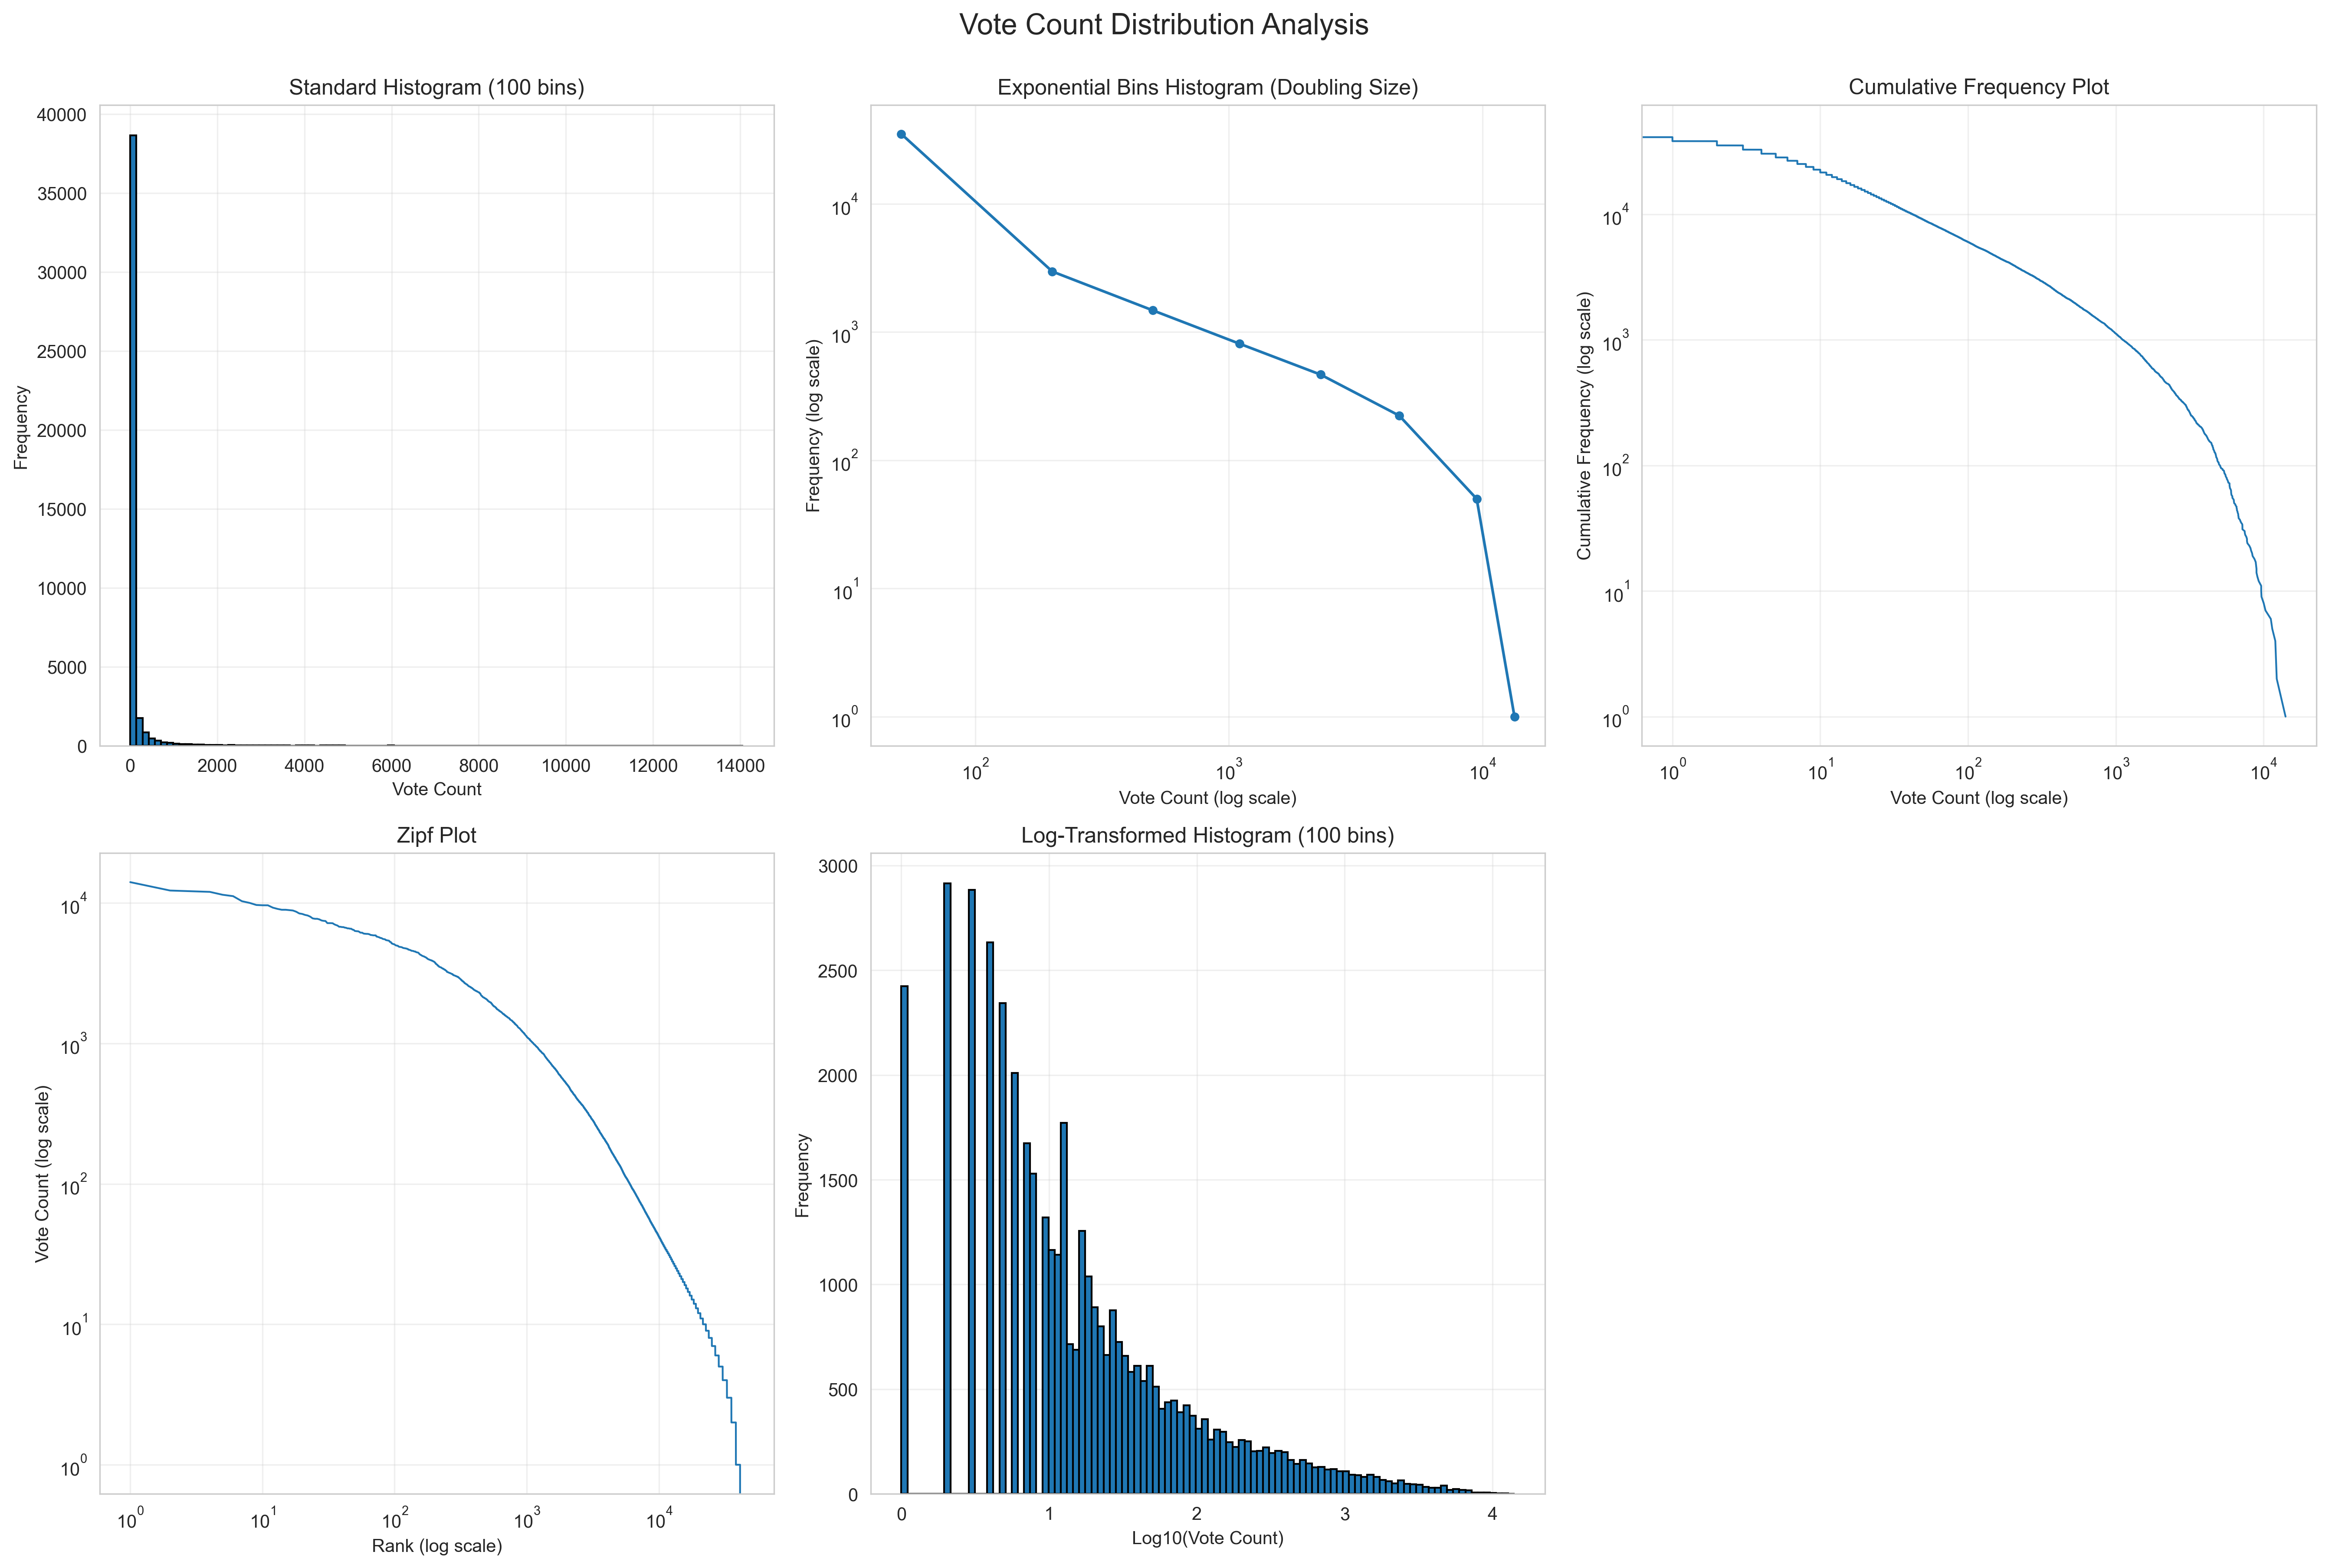

Σχολιασμός Κατανομής Vote Counts για τα 5 Γραφήματα
1. Ιστόγραμμα με 100 κάδους.
Το ιστόγραμμα παρουσιάζει μια εξαιρετικά ασύμμετρη κατανομή.
Οι περισσότερες ταινίες συγκεντρώνουν πολύ χαμηλές τιμές ψήφων (κοντά στο 1-50), ενώ οι υψηλές τιμές είναι σπάνιες.
Δηλαδή οι περισσότερες ταινίες είναι άγνωστες ή δεν τις έχει ψηφίσει πολύς κόσμος, ενώ λίγες ταινίες συγκεντρώνουν μεγάλο ενδιαφέρον.

2. Ιστόγραμμα με εκθετικούς κάδους.
Η κατανομή σε αυτό το ιστόγραμμα φαίνεται να παρουσιάζει μια σχεδον ευθεία φθίνουσα γραμμή. Κάτι που υποδεικνύει πως όσο μεγαλώνει ο αριθμός ψήφων τόσο λιγότερες είναι οι ταινίες που υπάρχουν με αυτόν.

3. Cumulative Frequency Plot.
Το cumulative frequency μειώνεται ομαλά καθώς αυξάνεται ο αριθμός των ψήφων. Από αυτό λαμβάνουμε πως υπάρχουν μεν ταινίες με πολύ μεγάλο αριθμό ψήφων αν και πολυ σπάνια.

4. Zipf Plot.
Η καμπύλη φαίνεται να είναι ομαλά φθίνουσα. Βέβαια για τις πρώτες 100 ταινίες για παράδειγμα μειώνεται πολύ ομαλά η δημοτικότητα τους, και στην συνέχεια φαίνεται να συμβαίνει το ίδιο ανα φάσεις. Αρα παρατηρούμε ότι η δημοτικότητα δεν μοιράζεται τυχαία αλλά οι περισσότερο δημοφιλείς ταινίες ειναι πολύ πιο δημοφιλείς απο τις λιγότερο.

5. Log-Transformed Ιστόγραμμα με 100 κάδους.
Η κατανομή γίνεται πιο ομαλή και μοιάζει περισσότερο συμμετρική απο το πρώτο ιστόγραμμα.Η λογαριθμική μετατροπή αποκαλύπτει μια πιο φυσική δομή των δεδομένων, που δείχνει πως οι ψήφοι πιθανώς αυξάνονται πολλαπλασιαστικά (όχι γραμμικά).

ΒΗΜΑ 3: Συσχετισμοί διάρκειας ταινίας με αξολόγιση/προυπολογισμό/κέρδη

In [5]:
def step3_runtime_correlation(df_clean):
    df_runtime = df_clean[
        (df_clean['runtime'] > 30) &
        (df_clean['vote_count'] > 10) &
        (df_clean['budget'] > 20000) &
        (df_clean['revenue'] > 20000)
    ].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Runtime vs. Other Features', fontsize=16)

    features = ['vote_average', 'budget', 'revenue']
    titles = ['Runtime vs Vote Avg', 'Runtime vs Budget', 'Runtime vs Revenue']

    for idx, (feature, title) in enumerate(zip(features, titles)):
        axes[idx].scatter(df_runtime['runtime'], df_runtime[feature],
                          alpha=0.5, s=20, edgecolors='none')
        axes[idx].set_xlabel('Runtime (minutes)')
        axes[idx].set_ylabel(feature.replace('_', ' ').title())
        axes[idx].set_title(title)
        axes[idx].grid(True, alpha=0.3)

        z = np.polyfit(df_runtime['runtime'].dropna(),
                       df_runtime[feature].dropna(), 1)
        p = np.poly1d(z)
        x_trend = np.linspace(df_runtime['runtime'].min(),
                              df_runtime['runtime'].max(), 100)
        axes[idx].plot(x_trend, p(x_trend), "r--", linewidth=2, alpha=0.7)

    plt.tight_layout()
    plt.savefig('step3_runtime_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nHypothesis: Longer movies have larger budgets but are less popular")

    for feature in features:
        correlation, p_value = stats.pearsonr(
            df_runtime['runtime'].dropna(),
            df_runtime[feature].dropna()
        )

        print(f"\n{feature.upper()}:")
        print(f"  Pearson Correlation: {correlation:.4f}")
        print(f"  P-value: {p_value:.4e}")

        if p_value < 0.001:
            sig = "*** (highly significant)"
        elif p_value < 0.01:
            sig = "** (very significant)"
        elif p_value < 0.05:
            sig = "* (significant)"
        else:
            sig = "(not significant)"

        print(f"  Interpretation: {sig}")

        if correlation > 0:
            direction = "positive (longer runtime - higher value)"
        else:
            direction = "negative (longer runtime - lower value)"
        print(f"Direction: {direction}")

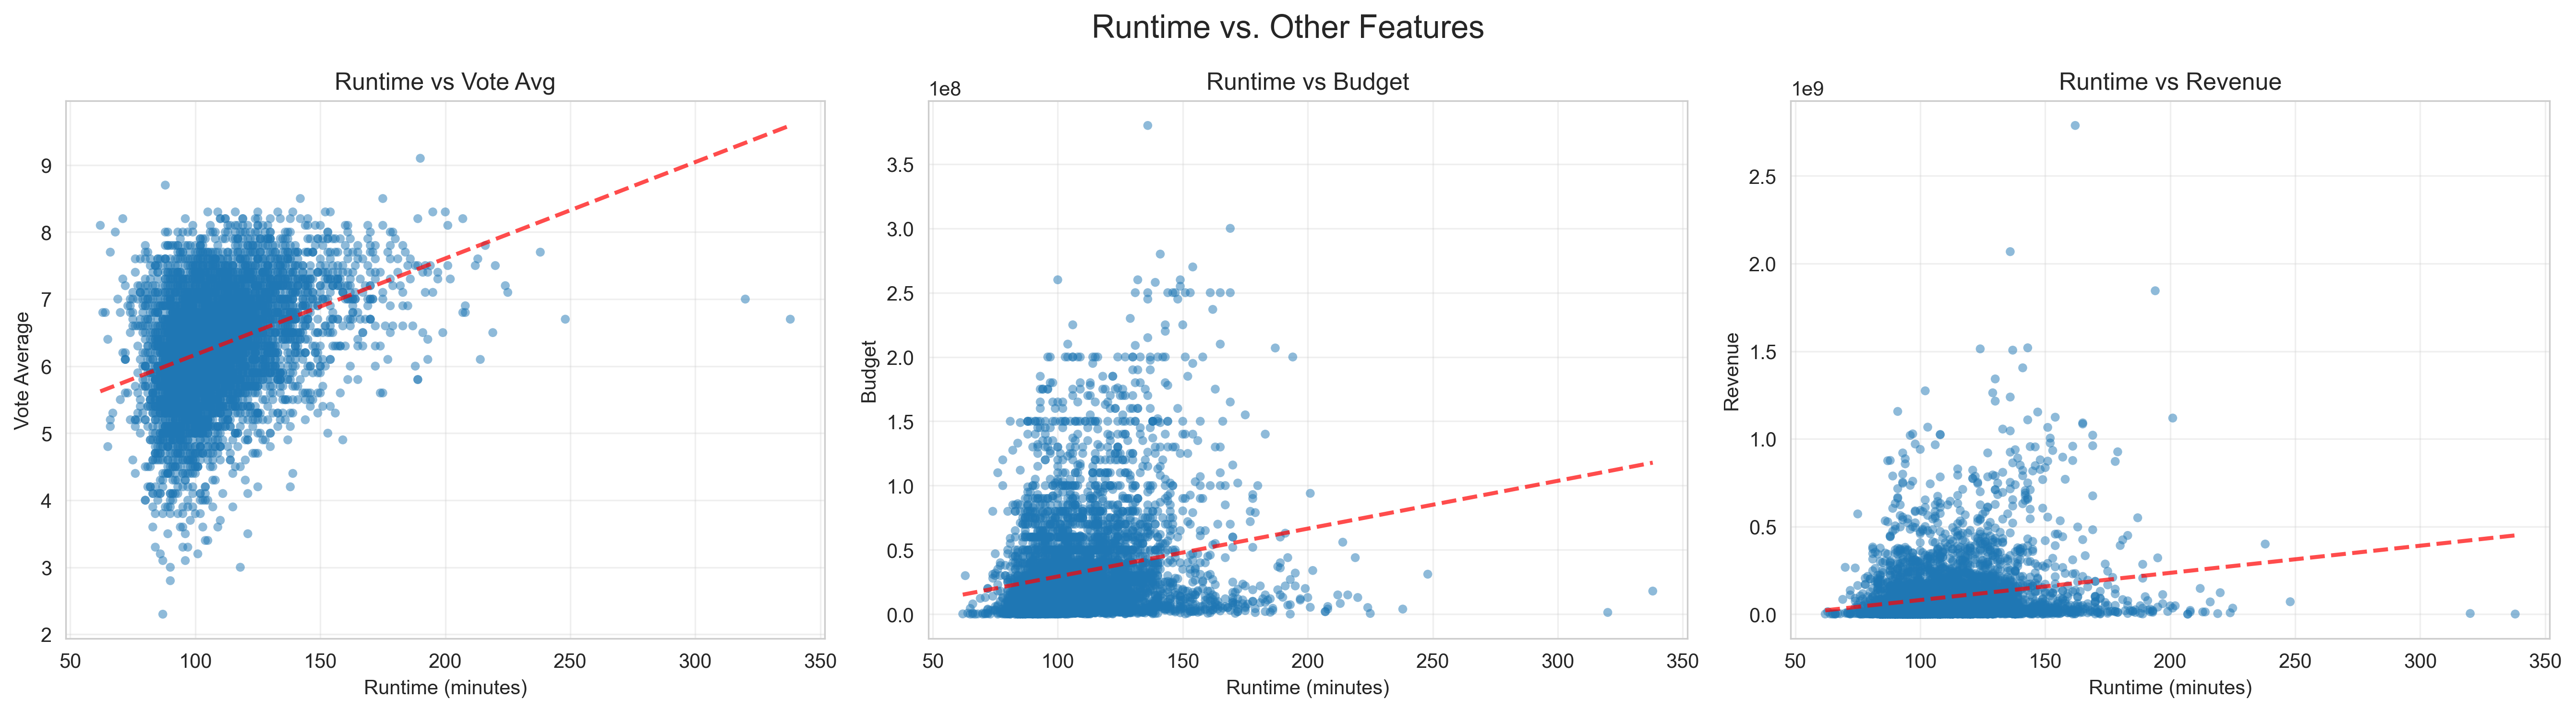

1. Runtime vs Vote Average.

Pearson correlation: 0.3576 (θετική μέτρια συσχέτιση)

P-value: ~1e-150 (πολύ στατιστικά σημαντική)

Υπάρχει ξεκάθαρη αλλά μέτρια θετική σχέση:
όσο μεγαλύτερη είναι η διάρκεια της ταινίας, τόσο ελαφρώς υψηλότερη τείνει να είναι η μέση βαθμολογία της.

2. Runtime vs Budget
Pearson correlation: 0.1930 (ασθενής θετική συσχέτιση)
P-value: ~3.9e-43 (πολύ στατιστικά σημαντική)

Υπάρχει μια αδύναμη αλλά θετική σχέση μεταξύ διάρκειας και προϋπολογισμού.
Δηλαδή, όσο πιο μεγάλη η ταινία, τόσο πιο πιθανό είναι να έχει μεγαλύτερο budget, αλλά η σχέση δεν είναι πολύ ισχυρή.
Υπάρχει τάση τα μεγάλα έργα να είναι ακριβότερα, αλλά η συσχέτιση είναι χαμηλή, άρα δεν μπορούμε να πούμε ότι η διάρκεια "καθορίζει" τον προϋπολογισμό.

3. Runtime vs Revenue
Pearson correlation: 0.1928 (ασθενής θετική συσχέτιση)
P-value: ~4.7e-43 (πολύ στατιστικά σημαντική)

Η σχέση είναι σχεδόν ίδια με τη σχέση με το budget: ασθενής αλλά θετική.
Οι μεγαλύτερες ταινίες έχουν ελαφρώς μεγαλύτερα έσοδα κατά μέσο όρο, αλλά η διασπορά είναι τεράστια.
Οι μεγάλες ταινίες τείνουν να έχουν λίγο μεγαλύτερα έσοδα, αλλά η διάρκεια από μόνη της δεν εξηγεί καλά τα έσοδα.

ΒΗΜΑ 4: Έλεγχος ποιότητας των ταινιών με βάση την δεκατία που βγήκαν.

In [6]:
def step4_quality_over_time(df_clean):
    df_quality = df_clean[df_clean['vote_count'] >= 10].copy()

    df_quality['year'] = df_quality['release_date'].dt.year
    df_quality['decade'] = (df_quality['year'] // 10) * 10

    decade_counts = df_quality['decade'].value_counts()
    print("Movies per decade:")
    print(decade_counts.sort_index())

    valid_decades = decade_counts[decade_counts >= 50].index
    df_quality = df_quality[df_quality['decade'].isin(valid_decades)]


    plt.figure(figsize=(14, 6))

    sns.lineplot(data=df_quality, x='decade', y='vote_average',
                 errorbar=('ci', 95), marker='o', linewidth=2, markersize=8)

    plt.xlabel('Decade', fontsize=12)
    plt.ylabel('Average Vote Rating', fontsize=12)
    plt.title('Movie Quality Over Time (95% Confidence Interval)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xticks(sorted(df_quality['decade'].unique()))
    plt.ylim(5.5, 7.5)
    plt.tight_layout()
    plt.savefig('step4_quality_over_time.png', dpi=300, bbox_inches='tight')
    plt.show()

    decade_stats = df_quality.groupby('decade')['vote_average'].agg([
        ('mean', 'mean'),
        ('median', 'median'),
        ('std', 'std'),
        ('count', 'count')
    ]).round(3)

    print(decade_stats)

    print("\n\nAlternative Analysis")

    df_balanced = df_quality.groupby('decade').apply(
        lambda x: x.nlargest(50, 'vote_count') if len(x) >= 50 else x
    ).reset_index(drop=True)

    plt.figure(figsize=(14, 6))

    sns.lineplot(data=df_balanced, x='decade', y='vote_average',
                 errorbar=('ci', 95), marker='s', linewidth=2, markersize=8, color='green')

    plt.xlabel('Decade', fontsize=12)
    plt.ylabel('Average Vote Rating', fontsize=12)
    plt.title('Movie Quality Over Time - Top 50 Most Popular Movies per Decade', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xticks(sorted(df_balanced['decade'].unique()))
    plt.tight_layout()
    plt.savefig('step4_quality_over_time_bonus.png', dpi=300, bbox_inches='tight')
    plt.show()


    return df_quality


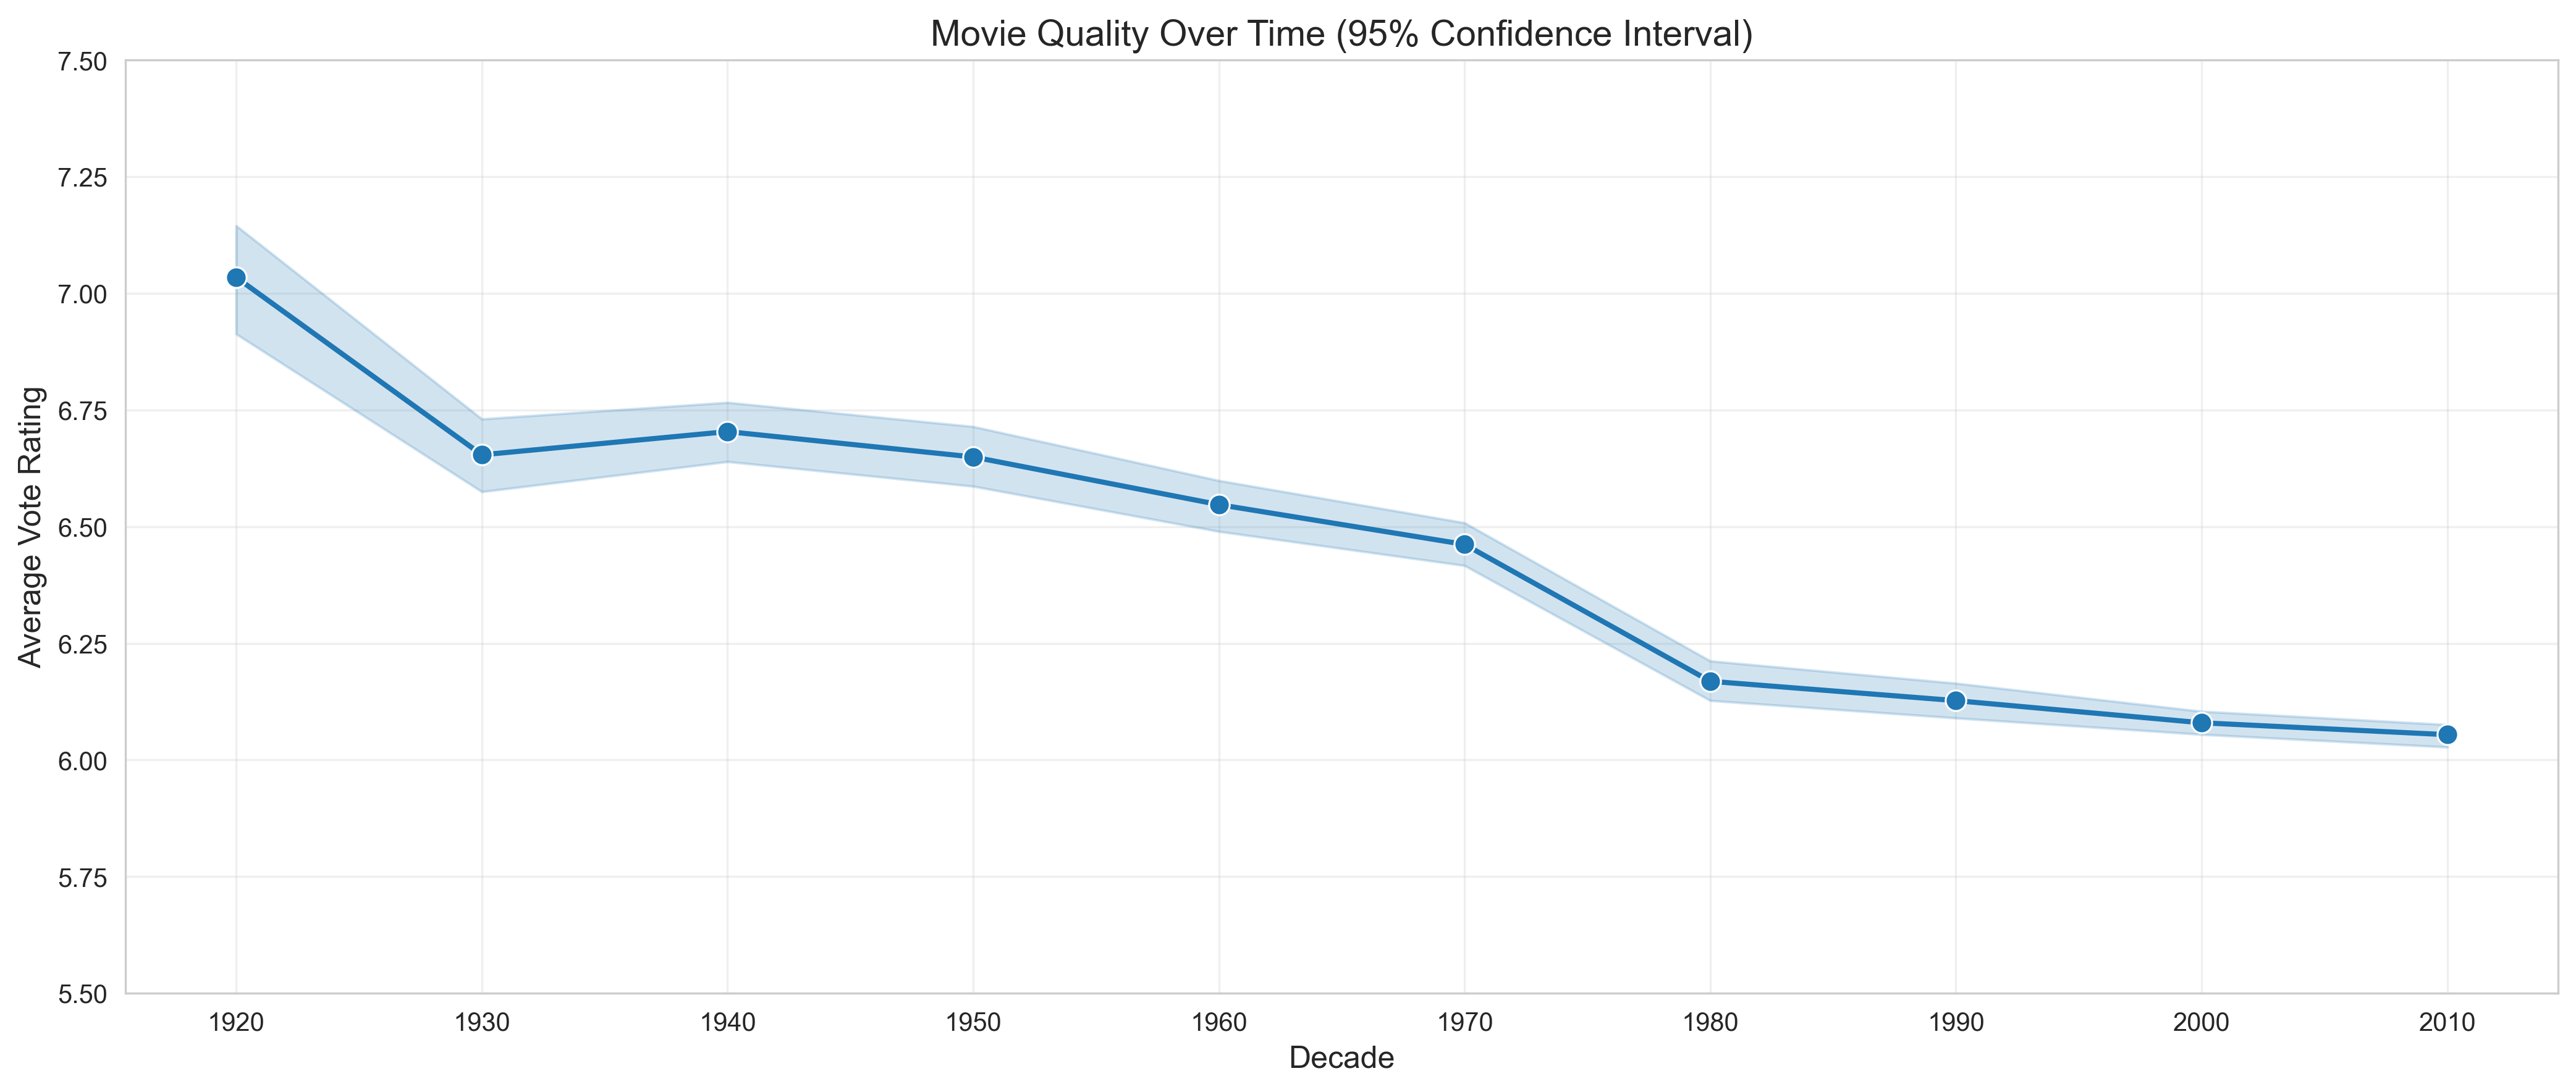

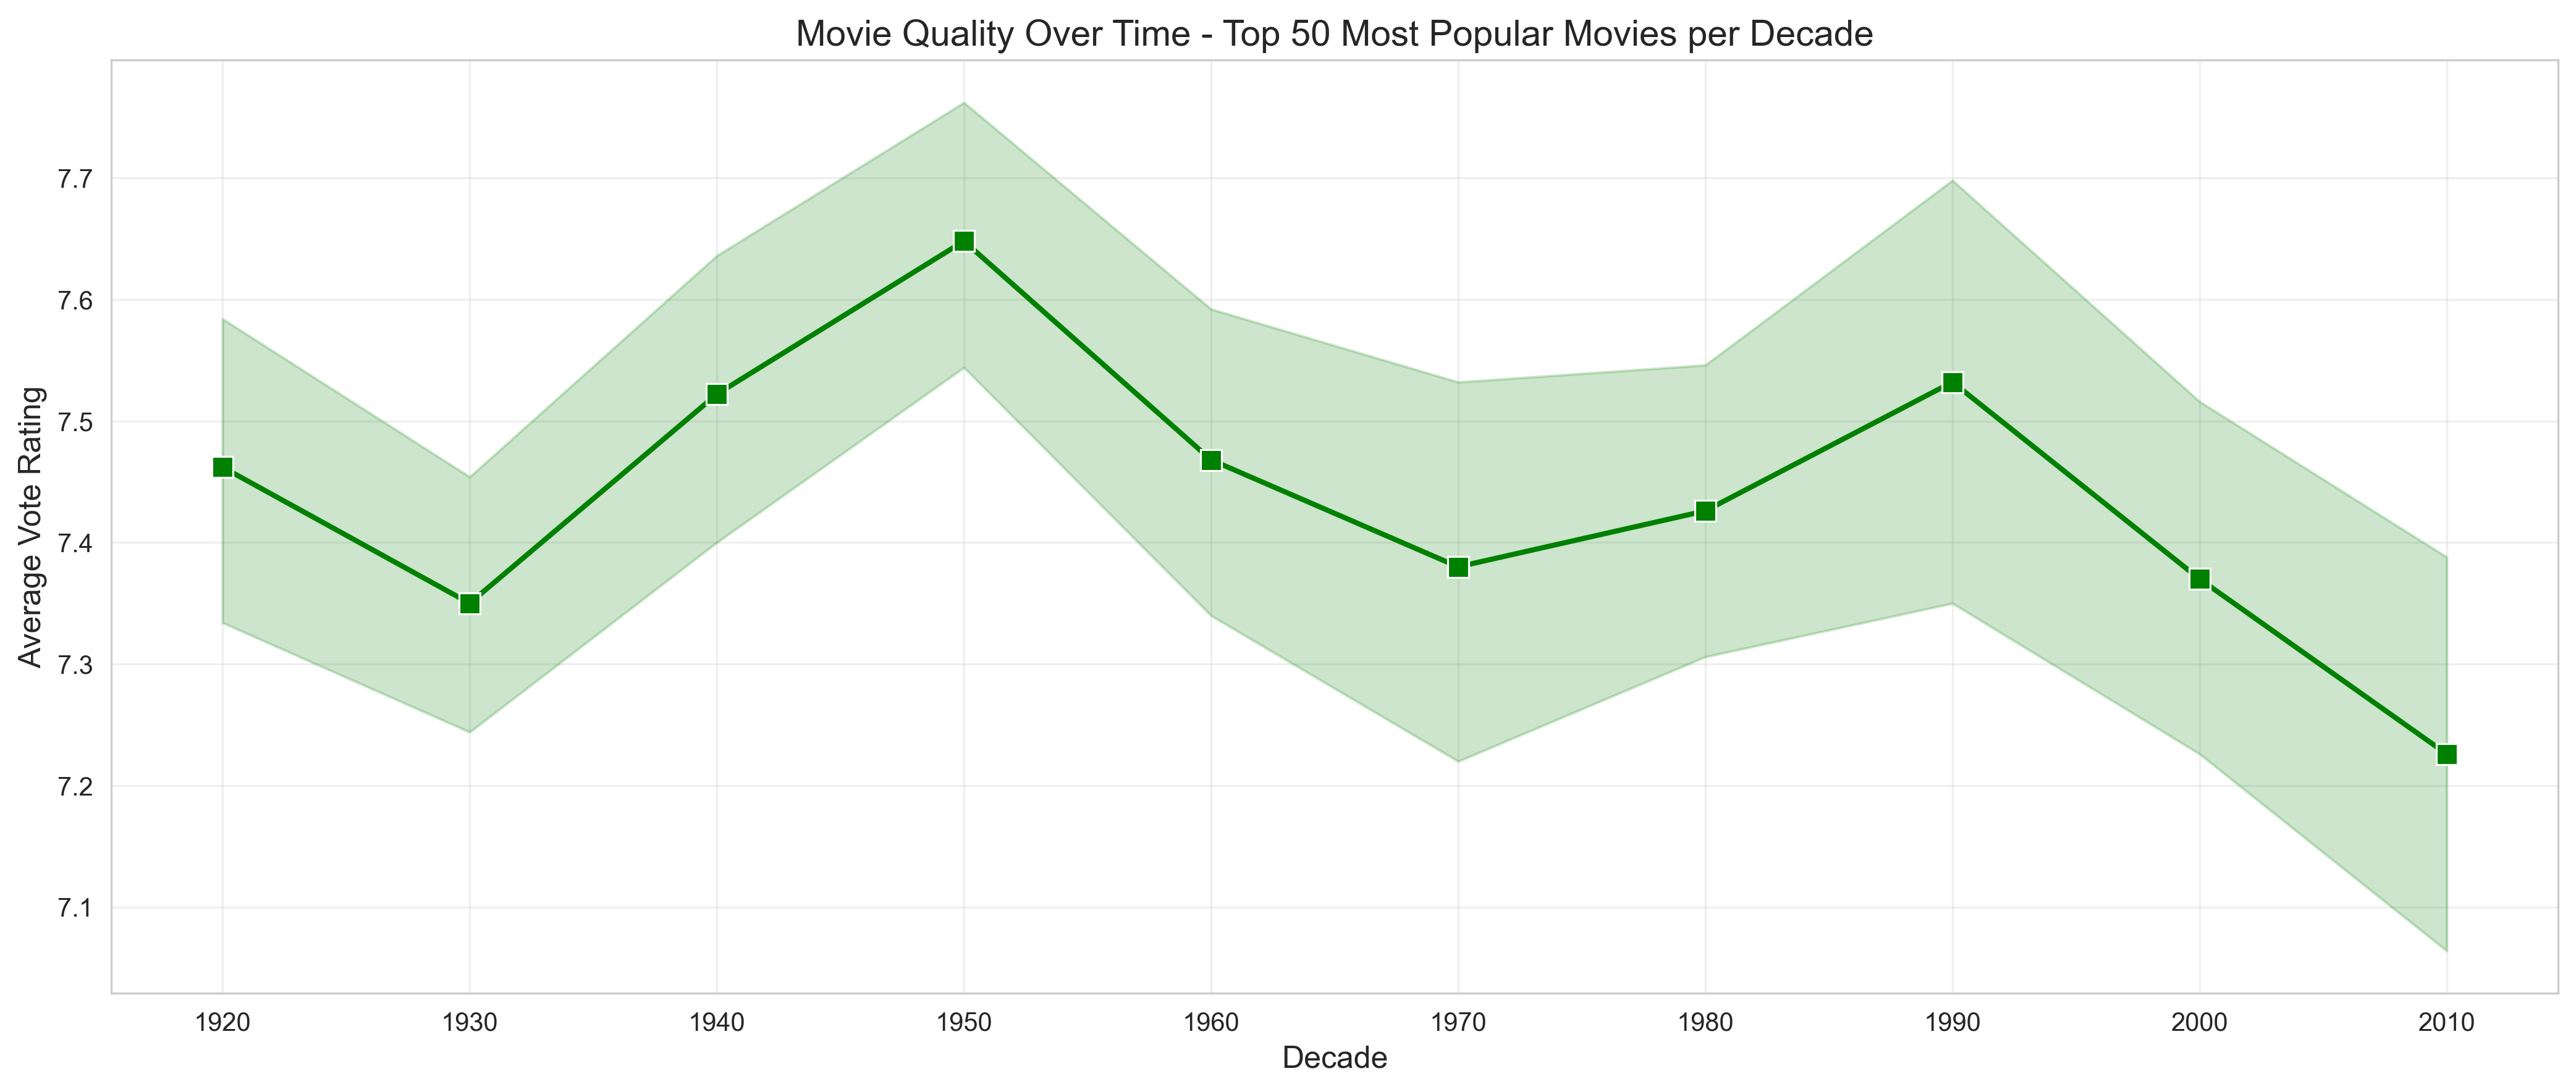

Παρατήρησεις για τα γραφήματα του 4.
Σύμφωνα με το πρώτο γράφημα φαίνεται να είναι αληθής η υπόθεση ότι η ποιότητα των ταινιών χειροτερεύει με τον χρόνο, ο μέσος όρος βαθμολογίας φθίνει μονίμος αν και φθίνει αργά. Βέβαια με το δεύτερο γράφημα όπου παρουσιάζοντε μόνο οι καλύτερες 50 ταινίες της κάθε δεκαετίας παρατηρούμε κορυφές στην δεκαετία του 50 και του 90.
Άρα θα μπορούσαμε ίσως να συμπεράνουμε , ότι ο μέσος όρος ποιότητας πέφτει επειδή αυξάνονται οι μέτριες ή οι κακές ταινίες.

ΒΗΜΑ 5: Συσχετισμοί φύλλου σκηνοθέτη και είδος ταινίας

In [7]:
def step5_gender_genre_correlation(df_clean):

    def parse_genres(genres_str):
        try:
            genres_list = literal_eval(genres_str)
            return [g['name'] for g in genres_list if 'name' in g]
        except:
            return []

    df_clean['genres_list'] = df_clean['genres'].apply(parse_genres)

    df_genres = df_clean[['id', 'genres_list']].copy()
    df_genres = df_genres.explode('genres_list')
    df_genres = df_genres.rename(columns={'genres_list': 'genre'})
    df_genres = df_genres.dropna(subset=['genre'])


    genre_counts = df_genres['genre'].value_counts()
    print("\nGenre distribution (top 10):")
    print(genre_counts.head(10))

    popular_genres = genre_counts[genre_counts > 100].index
    df_genres = df_genres[df_genres['genre'].isin(popular_genres)]

    print(f"\nKept {len(popular_genres)} genres with >100 movies")
    print(f"Filtered genre entries: {len(df_genres)}")

    df_credits = pd.read_csv('credits.csv')

    def get_director_info(crew_str):
        try:
            crew_list = literal_eval(crew_str)
            for person in crew_list:
                if person.get('job') == 'Director':
                    return person.get('gender', 0)
            return None
        except:
            return None

    df_credits['director_gender'] = df_credits['crew'].apply(get_director_info)

    df_directors = df_credits[['id', 'director_gender']].copy()
    df_directors = df_directors[df_directors['director_gender'].isin([1, 2])]

    df_directors['id'] = df_directors['id'].astype(str)

    print(f"\nTotal movies with directors: {len(df_directors)}")

    gender_counts = df_directors['director_gender'].value_counts()
    print("\nGender distribution:")
    print(f"Female (1): {gender_counts.get(1, 0)} ({gender_counts.get(1, 0)/len(df_directors)*100:.1f}%)")
    print(f"Male (2): {gender_counts.get(2, 0)} ({gender_counts.get(2, 0)/len(df_directors)*100:.1f}%)")

    df_merged = df_genres.merge(df_directors, on='id', how='inner')
    print(f"\nMerged dataset: {len(df_merged)} entries")

    contingency_table = pd.crosstab(
        df_merged['director_gender'],
        df_merged['genre'],
        margins=False
    )

    contingency_table.index = contingency_table.index.map({1: 'Female', 2: 'Male'})

    print(contingency_table)

    plt.figure(figsize=(14, 6))
    sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd',
                cbar_kws={'label': 'Count'})
    plt.title('Director Gender vs Movie Genre - Contingency Table', fontsize=14)
    plt.xlabel('Genre', fontsize=12)
    plt.ylabel('Director Gender', fontsize=12)
    plt.tight_layout()
    plt.savefig('step5_gender_genre_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

    print(f"\nChi-square statistic: {chi2:.2f}")
    print(f"\nP-value: {p_value:.4e}")
    print(f"\nDegrees of freedom: {dof}")

    if p_value < 0.001:
        print("Result: HIGHLY SIGNIFICANT correlation (p < 0.001)")
    else:
        print("Result: Correlation not significant (p > 0.001)")

    lift_table = contingency_table / expected
    lift_df = pd.DataFrame(lift_table,
                           index=contingency_table.index,
                           columns=contingency_table.columns)


    lift_values = []
    for gender in lift_df.index:
        for genre in lift_df.columns:
            lift_values.append((gender, genre, lift_df.loc[gender, genre]))

    lift_values.sort(key=lambda x: x[2], reverse=True)

    for i in range(min(3, len(lift_values))):
        gender, genre, lift = lift_values[i]

    for i in range(min(3, len(lift_values))):
        gender, genre, lift = lift_values[-(i+1)]

    return df_genres, df_directors


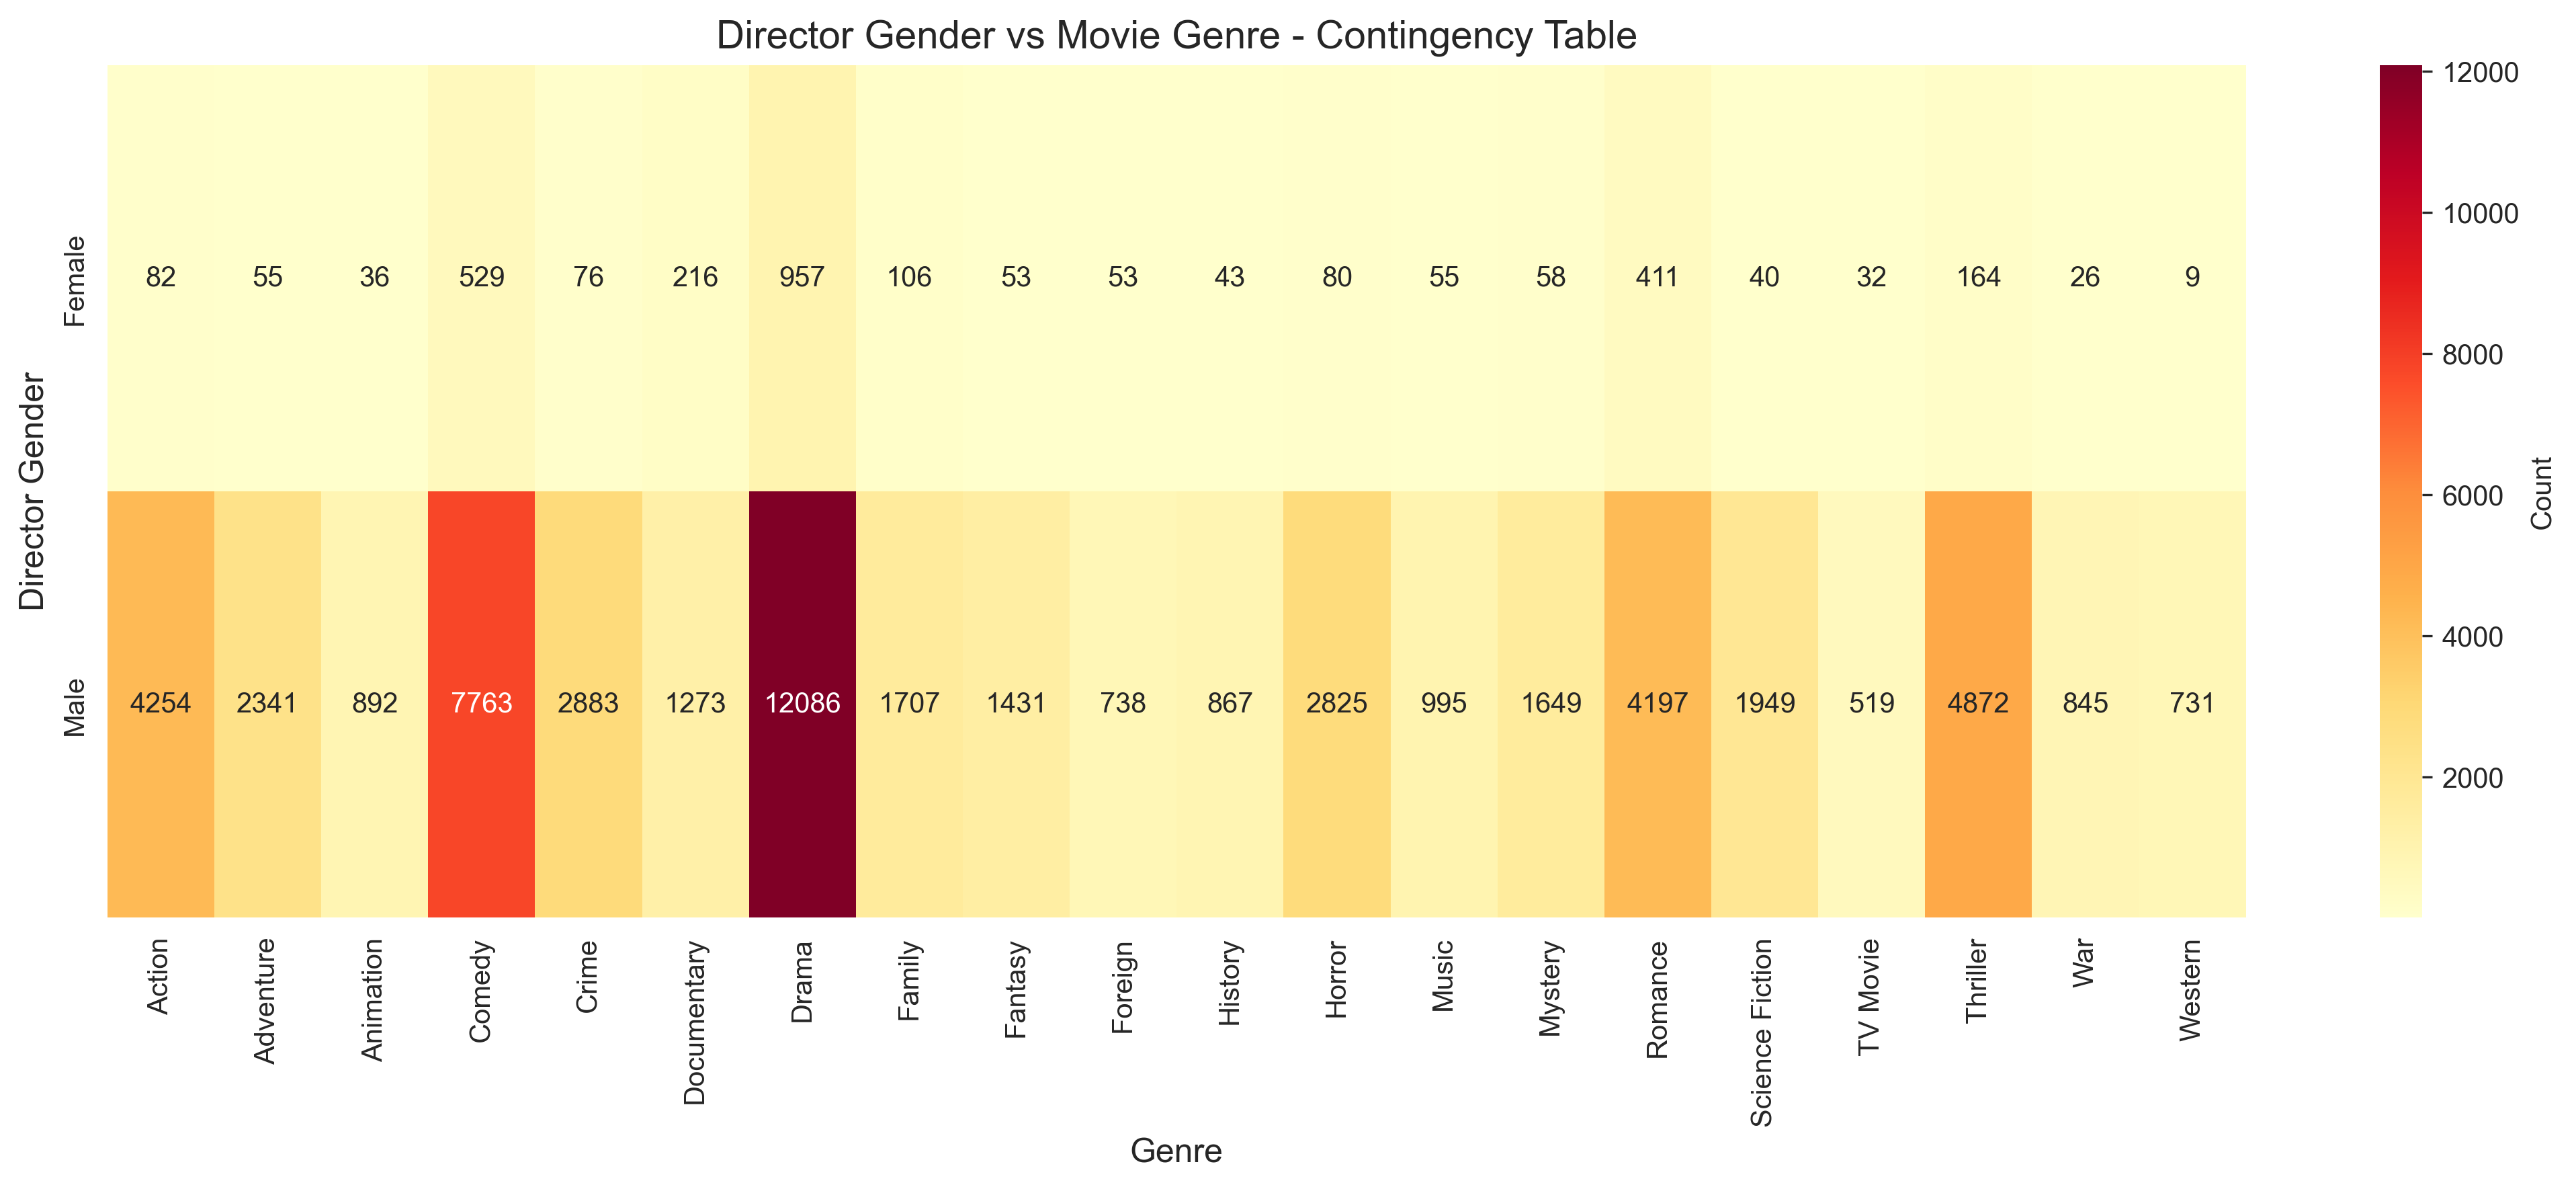

Για αρχή ένα απο αυτά που παρατηρούμε είναι ότι οι γυναίκες έχουν σημαντικά μικρότερο αριθμό ταινιών συνολικά σε σχέση με τους άντρες κάτι που επιδεικνύει πως η βομηχανία ταινιών είναι ιστορικά αδροκρατούμενη.
Δεν θ αμπορούσαμε με σιγουριά να πούμε πως το φύλλο εξαρτάται με την κατηγορία που επιλέγεται καθώς οι κατηγορίες που έχουν μεγαλύτερα ποσοστά οι γυναίκες είναι και αυτές που έχουν οι άντρες, αλλα μπορούμε να διακρίνουμε πως οι γυναίκες υποεκπροσωπούντε σε κάποια συγκεκρημένα genre όπως Action, Sci-Fi, Adventure, Western.

ΒΗΜΑ 6: Διαφορές μεταξύ Action και Drama ταινιών

In [8]:
def step6_action_vs_drama(df_clean, df_genres):
    df_comparison = df_genres[df_genres['genre'].isin(['Action', 'Drama'])].copy()

    df_comparison = df_comparison.merge(
        df_clean[['id', 'revenue', 'budget', 'vote_average']],
        on='id',
        how='inner'
    )

    df_comparison = df_comparison[
        (df_comparison['revenue'] > 0) &
        (df_comparison['budget'] > 0) &
        (df_comparison['vote_average'] > 0)
    ]

    print(f"Movies for comparison: {len(df_comparison)}")
    print(f"Action: {(df_comparison['genre'] == 'Action').sum()}")
    print(f"Drama: {(df_comparison['genre'] == 'Drama').sum()}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Action vs Drama - Comparison of Key Metrics', fontsize=16)

    attributes = ['revenue', 'budget', 'vote_average']
    titles = ['Revenue', 'Budget', 'Vote Average']

    for idx, (attr, title) in enumerate(zip(attributes, titles)):
        ax = axes[idx]

        sns.barplot(data=df_comparison, x='genre', y=attr,
                    errorbar=('ci', 95), ax=ax, palette='Set2')

        ax.set_xlabel('Genre', fontsize=12)
        ax.set_ylabel(title, fontsize=12)
        ax.set_title(f'{title} by Genre', fontsize=13)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('step6_action_vs_drama.png', dpi=300, bbox_inches='tight')
    plt.show()

    for attr, title in zip(attributes, titles):
        action_data = df_comparison[df_comparison['genre'] == 'Action'][attr].dropna()
        drama_data = df_comparison[df_comparison['genre'] == 'Drama'][attr].dropna()

        t_stat, p_value = stats.ttest_ind(action_data, drama_data)

        action_mean = action_data.mean()
        drama_mean = drama_data.mean()
        action_std = action_data.std()
        drama_std = drama_data.std()

        print(f"\n{title.upper()}:")
        print(f"Action - Mean: {action_mean:,.2f}, Std: {action_std:,.2f}")
        print(f"Drama  - Mean: {drama_mean:,.2f}, Std: {drama_std:,.2f}")
        print(f"Difference: {action_mean - drama_mean:,.2f}")
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.4e}")

        if p_value < 0.001:
            sig = "HIGHLY SIGNIFICANT"
        elif p_value < 0.01:
            sig = "VERY SIGNIFICANT"
        elif p_value < 0.05:
            sig = "SIGNIFICANT"
        else:
            sig = "NOT SIGNIFICANT"

        print(f"  Result: {sig}")

        if p_value < 0.05:
            if action_mean > drama_mean:
                print(f"Action movies have significantly HIGHER {title.lower()}")
            else:
                print(f"Drama movies have significantly HIGHER {title.lower()}")

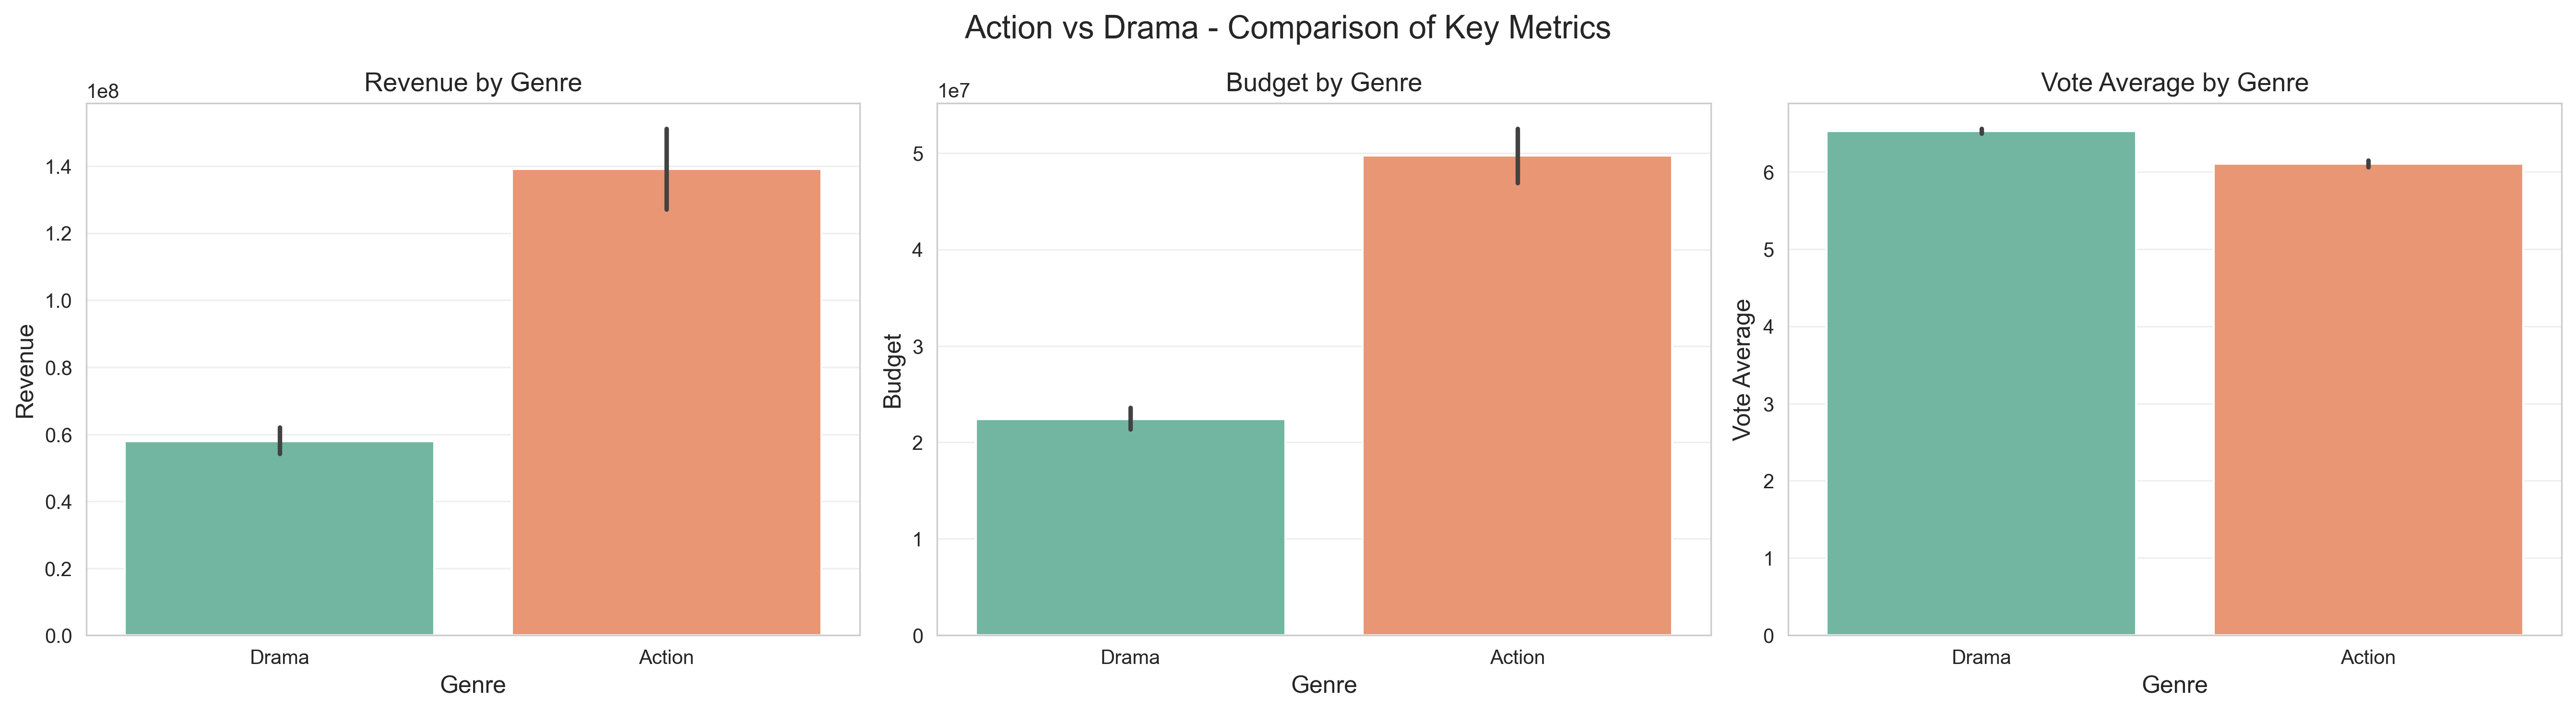

Από τα γραφήματα αλλά και απο τις μετρήσεις παρατηρούμε πώς:

1. Οι action ταινίες έχουν σημαντικα μεγαλύτερα κέρδη απο τις drama ταινίες

2. Οι action ταινίες έχουν σημαντικα μεγαλύτερο budget απο τις drama ταινίες

3. Οι drama ταινίες έχουν σημαντικα μεγαλύτερη αξιολόγιση απο τις action ταινίες

Αυτό οφείλετε κατα την γνώμη μας στο γεγονός ότι οι ταινίες δράσης έχουν σαφώς μεγαλύτερο κοινό (εξού και τα περισσότερα κέρδη) και αυτό επηρεάζει το ρίσκο στο οποίο θα μπούν οι παραγωγοί τους (εξού και το μεγαλύτερο budget).

Σε αντίθεση βέβαια με αυτά φαίνεται πως οι drama ταινίες έχουν μεγαλύτερες αξιλογίσεις , δηλαδή θεωρούντε πιο ποιοτηκές, αυτο ίσως μπορεί να εξηγηθεί θεωρώντας πως είναι πολύ πιο δύσκολες στην κατανόηση και την παρακολούθηση καθώς , ως τέχνη, αποσκοπούν στο να γεννούν μεγάλο πλήθος συναισθημάτων και να περνούν περισσότερα μηνύματα στον θεατή κάτι που τις καθιστά λιγότερο εύπεπτες σε σχέση με τις action ταινίες που συνήθως αποσκοπούν σε λιγότερο "βαριά" συναισθήματα η μηνύματα. Έτσι για τους κρητικούς ταινιών οι ταινίες drama πολλές φορές βαθμολογούντε καλύτερα.

BHMA 7: Έλεγχος διαφοράς του προυπολογισμού της ταινίας με βάση το φύλλο σκηνοθέτη

In [9]:
def step7_gender_budget_hypothesis(df_clean, df_directors):
    print("Hypothesis: 'Female directors have smaller budgets than male directors'")

    df_budget = df_clean[['id', 'budget']].copy()
    df_budget['id'] = df_budget['id'].astype(str)

    df_analysis = df_budget.merge(df_directors, on='id', how='inner')

    df_analysis = df_analysis[df_analysis['budget'] > 0]

    print(f"\nMovies with valid budget and director gender: {len(df_analysis)}")

    female_budgets = df_analysis[df_analysis['director_gender'] == 1]['budget']
    male_budgets = df_analysis[df_analysis['director_gender'] == 2]['budget']

    print(f"\nFemale directors: {len(female_budgets)} movies")
    print(f"Male directors: {len(male_budgets)} movies")


    print(f"\nFemale Directors:")
    print(f"Mean budget: ${female_budgets.mean():,.0f}")
    print(f"Median budget: ${female_budgets.median():,.0f}")
    print(f"Std deviation: ${female_budgets.std():,.0f}")

    print(f"\nMale Directors:")
    print(f"Mean budget: ${male_budgets.mean():,.0f}")
    print(f"Median budget: ${male_budgets.median():,.0f}")
    print(f"Std deviation: ${male_budgets.std():,.0f}")

    statistic, p_value = stats.mannwhitneyu(female_budgets, male_budgets, alternative='less')

    print(f"Test statistic: {statistic:,.0f}")
    print(f"P-value: {p_value:.6f}")

    if p_value < 0.001:
        print("Result: HIGHLY SIGNIFICANT (p < 0.001)")
        print("Conclusion: Female directors have significantly lower budgets than male directors")
    elif p_value < 0.05:
        print("Result: SIGNIFICANT (p < 0.05)")
        print("Conclusion: Female directors have significantly lower budgets than male directors")
    else:
        print("Result: NOT SIGNIFICANT (p >= 0.05)")
        print("Conclusion: No significant difference in budgets between genders")

    plt.figure(figsize=(10, 6))

    df_plot = df_analysis.copy()
    df_plot['Gender'] = df_plot['director_gender'].map({1: 'Female', 2: 'Male'})

    sns.barplot(data=df_plot, x='Gender', y='budget',
                order=['Female', 'Male'],
                errorbar=('ci', 95), palette=['#FF69B4', '#4169E1'])

    plt.ylabel('Mean Budget (USD)', fontsize=12)
    plt.xlabel('Director Gender', fontsize=12)
    plt.title('Mean Movie Budget by Director Gender (95% Confidence Interval)', fontsize=14, pad=20)
    plt.ticklabel_format(style='plain', axis='y')

    mean_female = female_budgets.mean()
    mean_male = male_budgets.mean()
    plt.text(0, mean_female, f'${mean_female:,.0f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
    plt.text(1, mean_male, f'${mean_male:,.0f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('step7_gender_budget_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    ratio = male_budgets.mean() / female_budgets.mean()
    print(f"Male directors have {ratio:.2f}x the mean budget of female directors")
    print(f"Difference in means: ${male_budgets.mean() - female_budgets.mean():,.0f}")

    return df_analysis


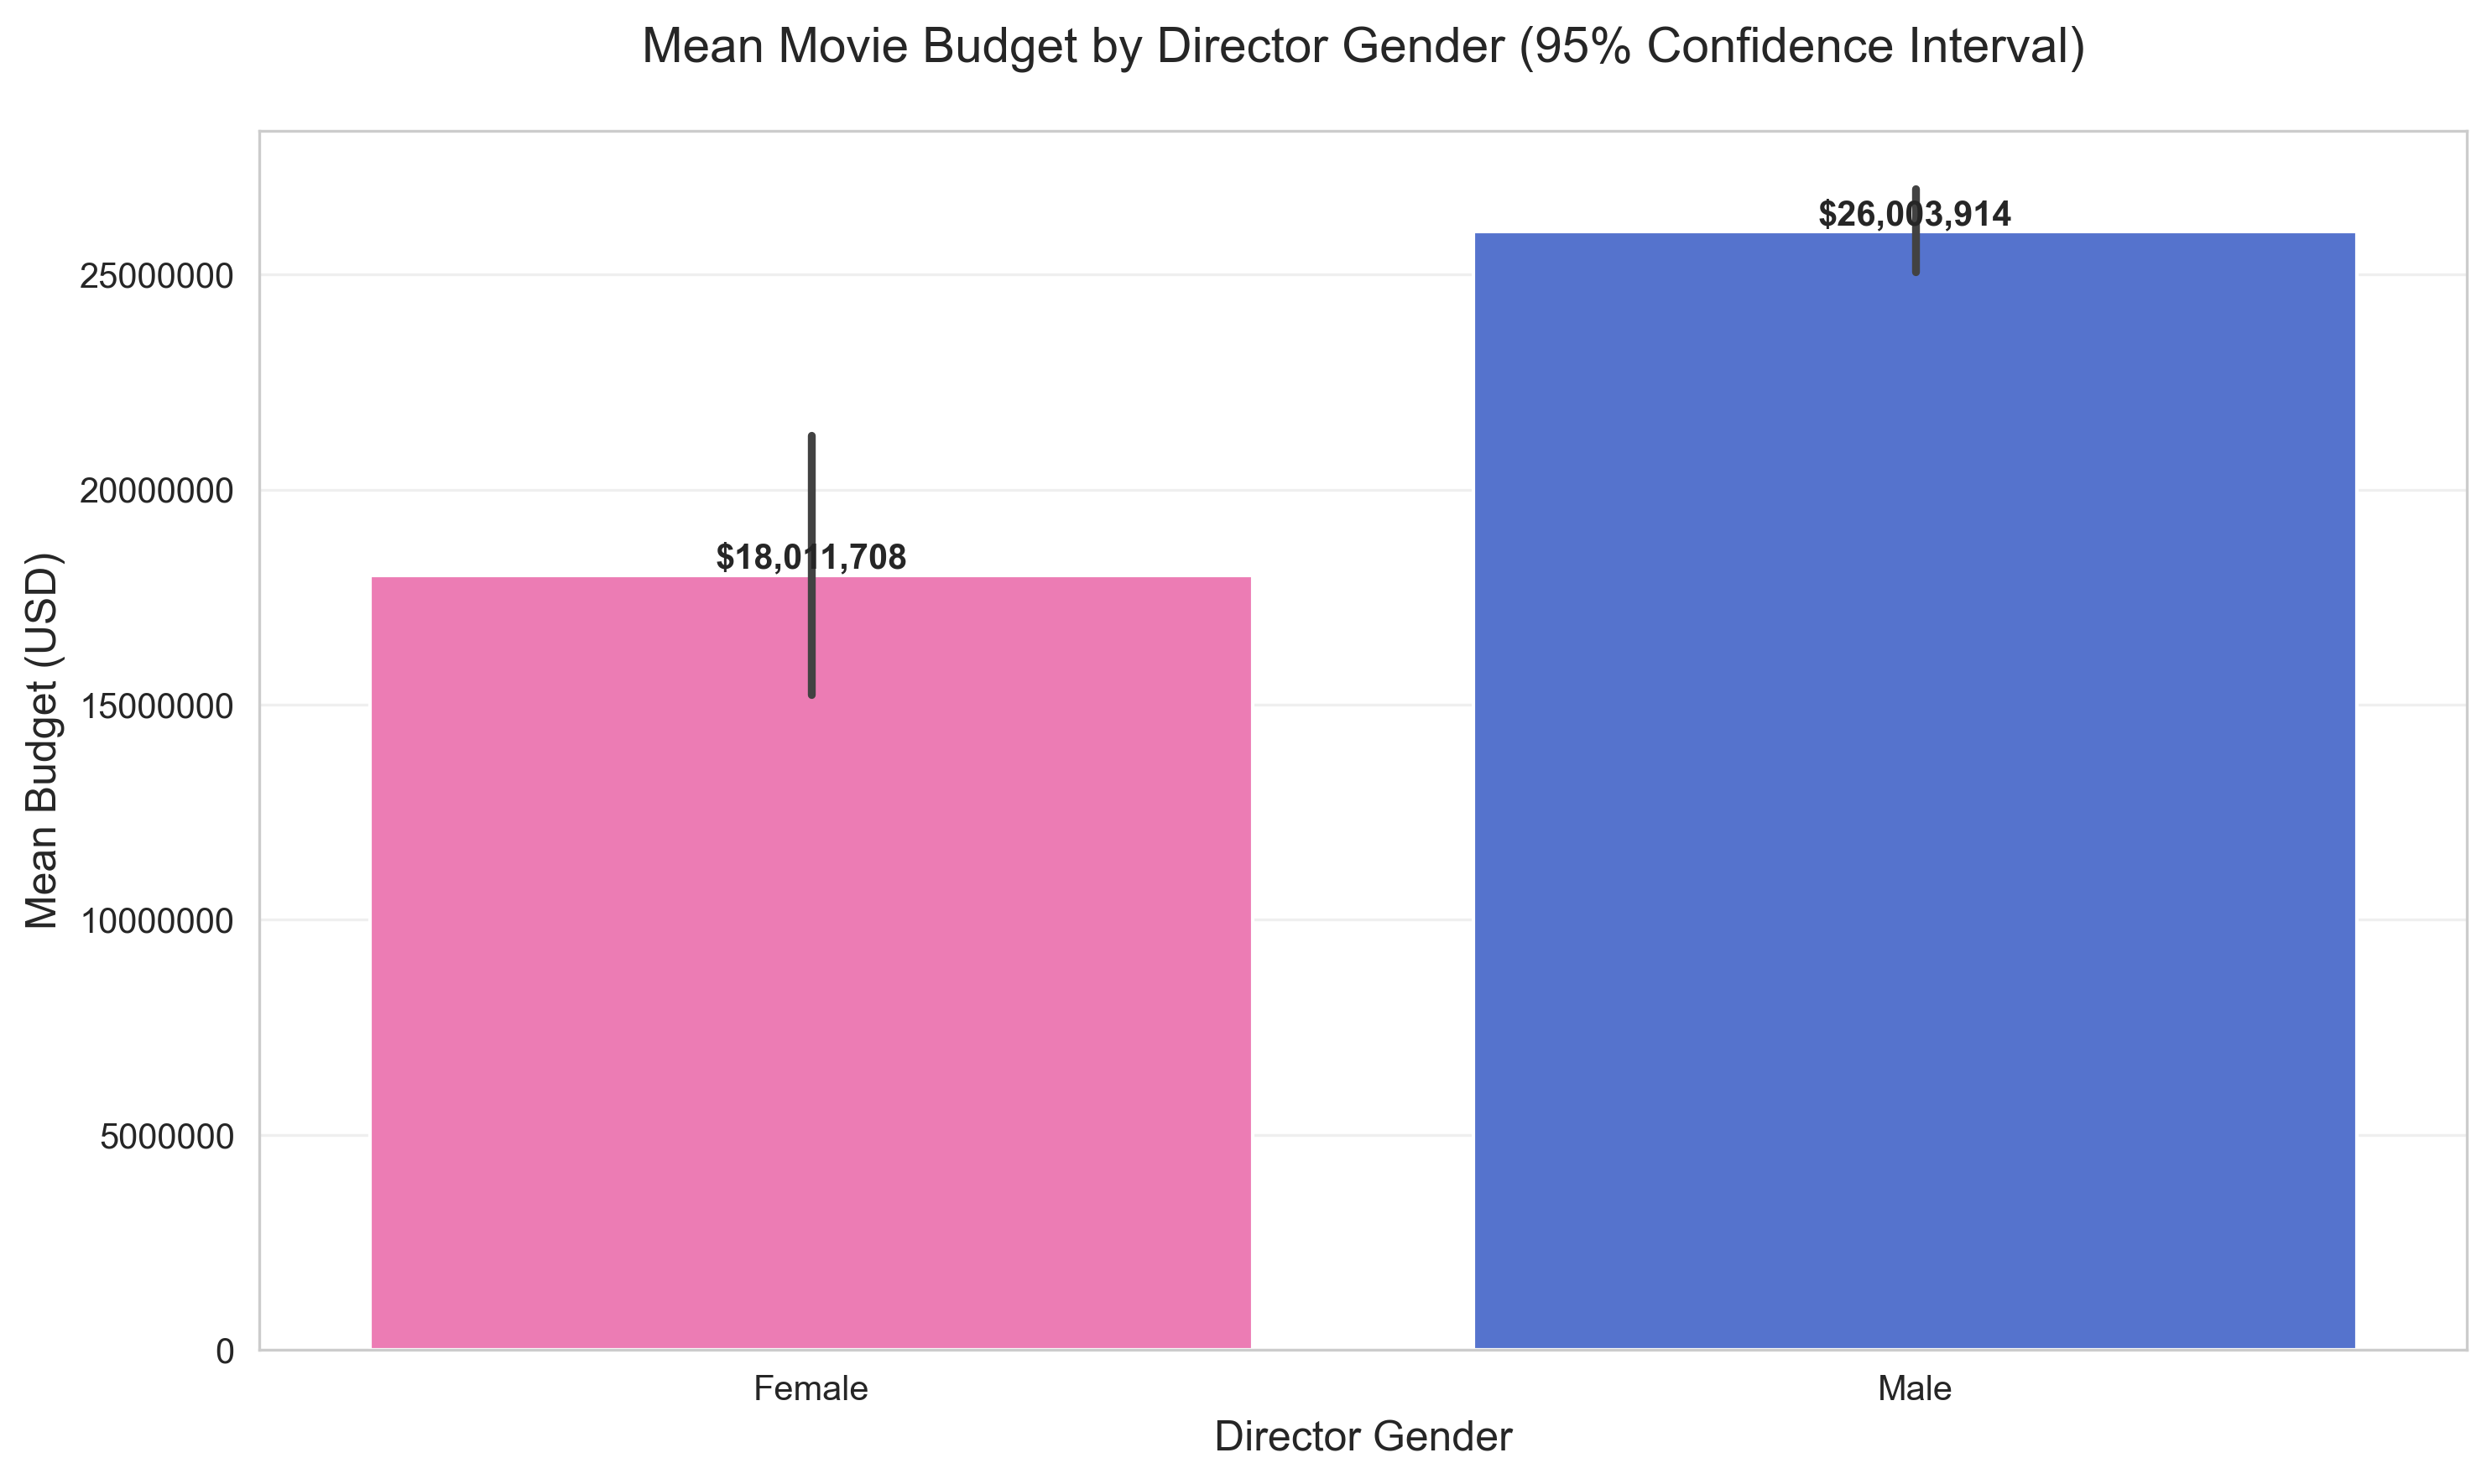

Απο το παραπάνω γράφημα αλλά και απο τις μετρήσεις πόσο παρατηρούμε σημαντική είναι η διαφορά τους προυπολογισμού ταινιών με βάση το φύλλο του σκηνοθέτη. Οι γυναίκες ξεκάθαρα έχουν πολύ μικρότερο προυπολογισμό σε σχέση με τους άντρες κατι που επίσης μας υποδεικνύει πόσο ανρδοκρατούμενη και πατριαρχική είναι η βιομηχανία.

ΒΗΜΑ 8: Προσωπική Υπόθεση

Υποθέσαμε πως οι ταινίες κινουμένων σχεδίων έχουν υψηλότερο budget από τα άλλα είδη

In [10]:
def step8_custom_hypothesis(df_clean, df_genres):
    print("Hypothesis: 'Animated movies have higher vote averages than other genres'")
    print("Rationale: Usually animated movies are specifically targeted and well-received by audiences leading to higher votes")

    df_runtime_genre = df_genres.merge(
        df_clean[['id', 'vote_average']],
        on='id',
        how='inner'
    )

    df_runtime_genre = df_runtime_genre[df_runtime_genre['vote_average'] > 0]

    animation = df_runtime_genre[
        df_runtime_genre['genre'] == 'Animation'
    ].copy()
    animation['genre_group'] = 'Animation'

    other_genres = df_runtime_genre[
        df_runtime_genre['genre'] != 'Animation'
    ].copy()
    other_genres['genre_group'] = 'Other Genres'

    df_hypothesis = pd.concat([animation, other_genres])

    print(f"\nDataset for analysis:")
    print(f"Animation movies: {len(animation)}")
    print(f"Other genre movies: {len(other_genres)}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Vote Average: Animation vs Other Genres', fontsize=16)

    ax1 = axes[0]
    ax1.hist(animation['vote_average'], bins=30, alpha=0.6,
             label='Animation', edgecolor='black')
    ax1.hist(other_genres['vote_average'], bins=30, alpha=0.6,
             label='Other Genres', edgecolor='black')
    ax1.set_xlabel('Vote Average', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Vote Average Histograms', fontsize=13)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    ax2 = axes[1]
    sns.barplot(data=df_hypothesis, x='genre_group', y='vote_average',
                errorbar=('ci', 95), ax=ax2, palette='Set2')
    ax2.set_xlabel('Genre Group', fontsize=12)
    ax2.set_ylabel('Mean Vote Average', fontsize=12)
    ax2.set_title('Mean Vote Average with 95% Confidence Interval', fontsize=13)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('step8_custom_hypothesis.png', dpi=300, bbox_inches='tight')
    plt.show()

    anim_votes = animation['vote_average']
    other_votes = other_genres['vote_average']

    print(f"\nAnimation:")
    print(f"Count: {len(anim_votes)}")
    print(f"Mean: {anim_votes.mean():.2f}")
    print(f"Median: {anim_votes.median():.2f}")
    print(f"Std Dev: {anim_votes.std():.2f}")
    print(f"Range: [{anim_votes.min():.1f}, {anim_votes.max():.1f}]")

    print(f"\nOther Genres:")
    print(f"Count: {len(other_votes)}")
    print(f"Mean: {other_votes.mean():.2f}")
    print(f"Median: {other_votes.median():.2f}")
    print(f"Std Dev: {other_votes.std():.2f}")
    print(f"Range: [{other_votes.min():.1f}, {other_votes.max():.1f}]")

    print(f"\nDifference in means: {anim_votes.mean() - other_votes.mean():.2f}")

    t_stat, p_value_ttest = stats.ttest_ind(anim_votes, other_votes)

    print(f"Null hypothesis: Animation and Other genres have equal mean vote average")
    print(f"Alternative: Mean vote averages are different")
    print(f"\nT-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value_ttest:.4e}")

    if p_value_ttest < 0.001:
        print("HIGHLY SIGNIFICANT (p < 0.001)")
    elif p_value_ttest < 0.01:
        print("VERY SIGNIFICANT (p < 0.01)")
    elif p_value_ttest < 0.05:
        print("SIGNIFICANT (p < 0.05)")
    else:
        print("NOT SIGNIFICANT (p >= 0.05)")

    u_stat, p_value_mann = stats.mannwhitneyu(anim_votes, other_votes,
                                              alternative='two-sided')

    print("(Non-parametric alternative, doesn't assume normal distribution)")
    print(f"U-statistic: {u_stat:.4f}")
    print(f"P-value: {p_value_mann:.4e}")

    if p_value_mann < 0.05:
        print("Result: STATISTICALLY SIGNIFICANT")
    else:
        print("Result: NOT SIGNIFICANT")

    pooled_std = np.sqrt(((len(anim_votes)-1)*anim_votes.std()**2 +
                          (len(other_votes)-1)*other_votes.std()**2) /
                         (len(anim_votes) + len(other_votes) - 2))
    cohens_d = (anim_votes.mean() - other_votes.mean()) / pooled_std

    print(f"Cohen's d: {cohens_d:.4f}")
    if abs(cohens_d) < 0.2:
        effect = "SMALL"
    elif abs(cohens_d) < 0.5:
        effect = "MEDIUM"
    else:
        effect = "LARGE"
    print(f"Interpretation: {effect} effect size")

    genre_vote_stats = df_runtime_genre.groupby('genre')['vote_average'].agg([
        ('count', 'count'),
        ('mean', 'mean'),
        ('median', 'median'),
        ('std', 'std')
    ]).round(2)

    genre_vote_stats = genre_vote_stats.sort_values('mean', ascending=False)
    print(genre_vote_stats)

    genre_groups = [group['vote_average'].values for name, group in
                    df_runtime_genre.groupby('genre')]
    f_stat, p_value_anova = stats.f_oneway(*genre_groups)

    print(f"F-statistic: {f_stat:.4f}")
    print(f"P-value: {p_value_anova:.4e}")

    if p_value_anova < 0.05:
        print("Result: At least one genre has significantly different vote average")
    else:
        print("Result: No significant differences among genres")

    if p_value_ttest < 0.05:
        if anim_votes.mean() > other_votes.mean():
            print("HYPOTHESIS SUPPORTED:")
            print(f"Animation movies have significantly HIGHER vote averages")
            print(f"({anim_votes.mean():.2f} vs {other_votes.mean():.2f})")
            print(f"Difference: {anim_votes.mean() - other_votes.mean():.2f} points")
        else:
            print("HYPOTHESIS REJECTED:")
            print("Animation movies actually have LOWER vote averages than other genres")
    else:
        print("HYPOTHESIS NOT SUPPORTED:")
        print(" No statistically significant difference in vote averages")

    print(f"\nStatistical Significance: p = {p_value_ttest:.4e}")
    print(f"Effect Size: Cohen's d = {cohens_d:.4f} ({effect})")

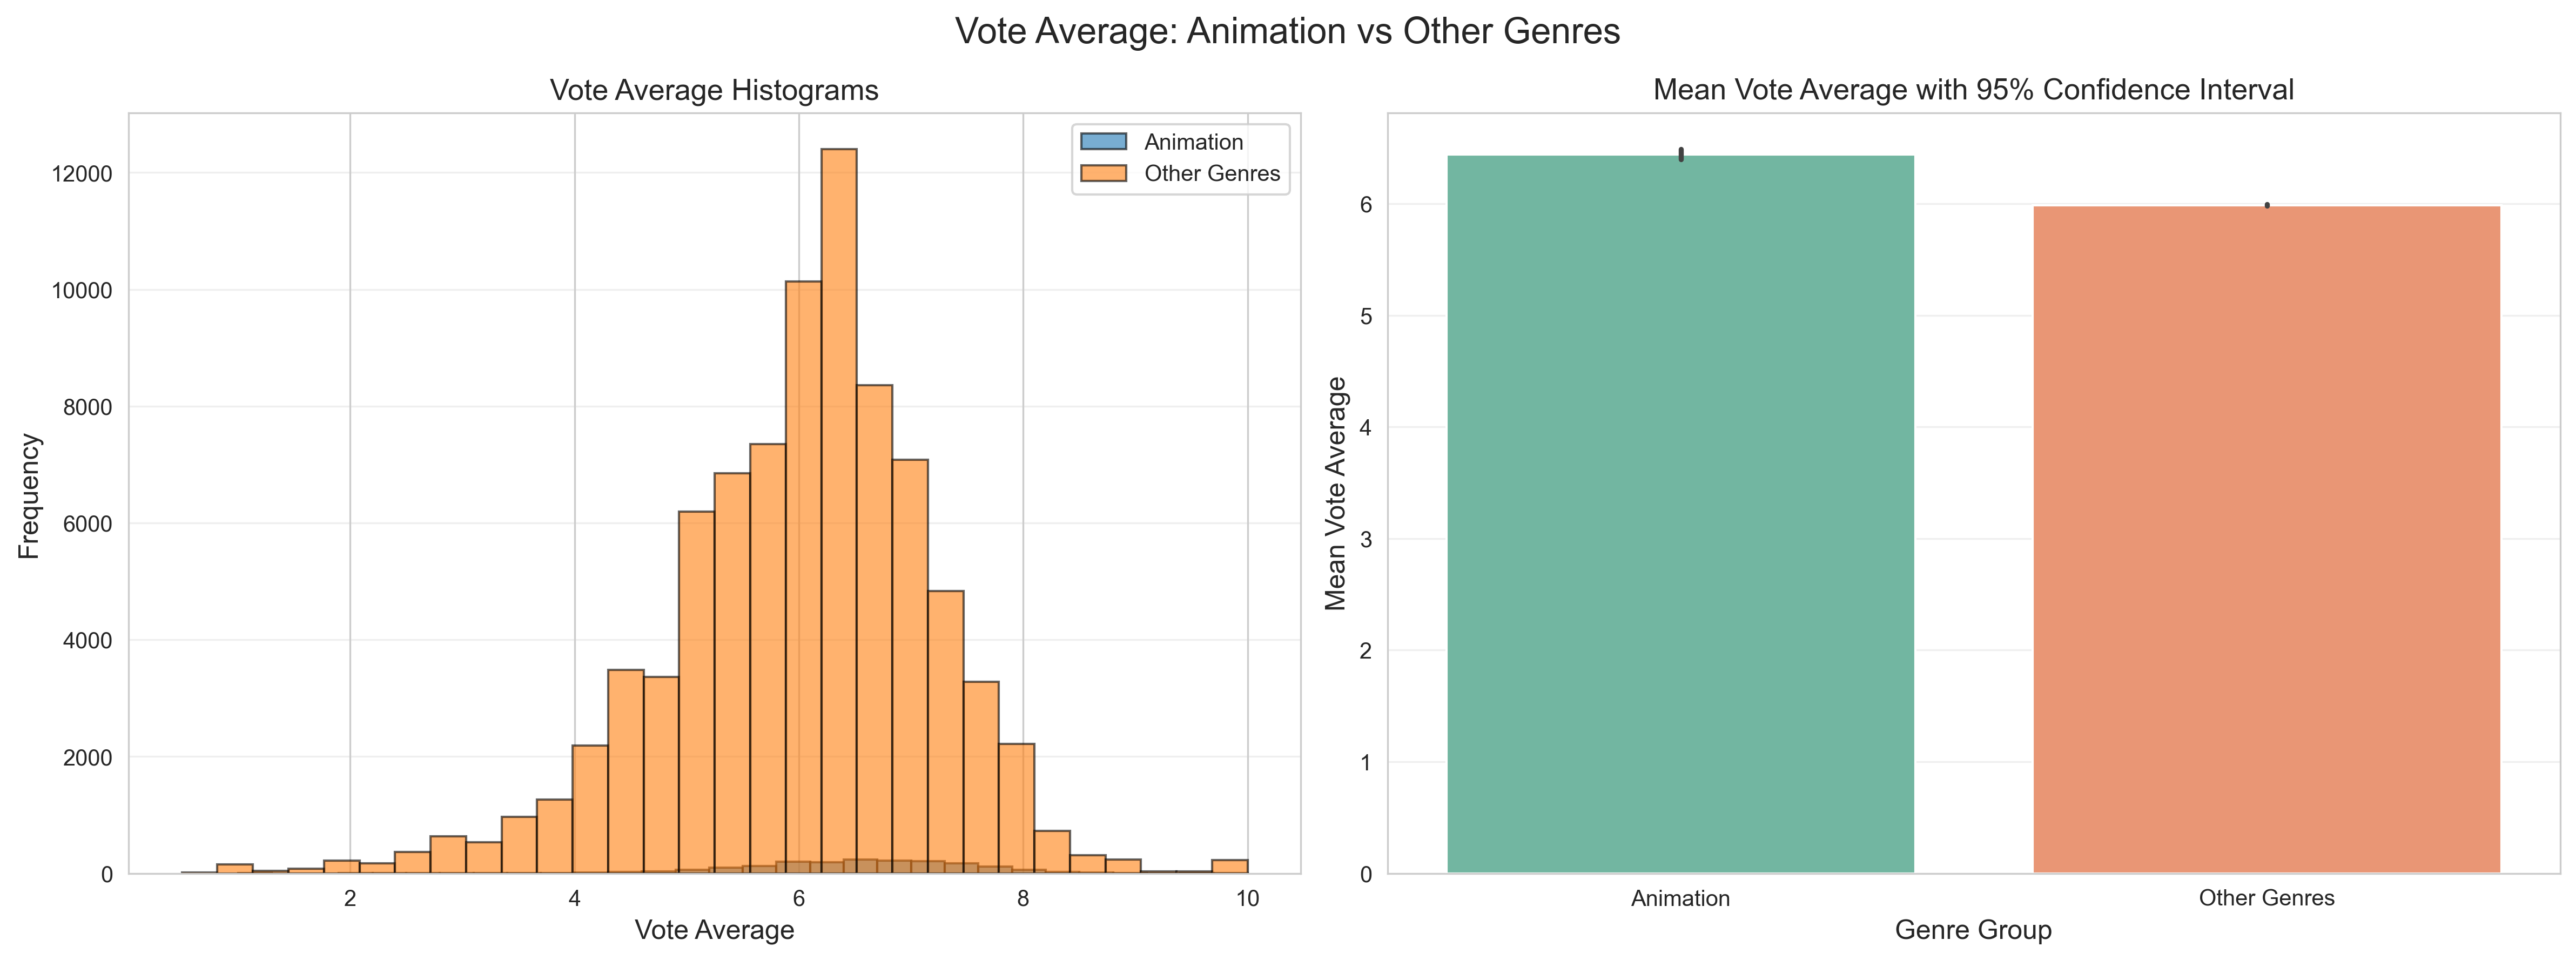

Τέλος η υπόθεση μας ήταν πως οι ταινίες κινουμένων σχεδίων έχουν σημαντικά μεγαλύτερη αξιολόγιση από τα υπόλοιπα genres.
σύμφωνα με τα γραφήματά μας και τις μετρήσεις μας φαίνεται πως η υπόθεση μας υποστηρίζεται καθώς ο μέσος όρος αξιολόγισης ταινιών κινουμένων σχεδίων είναι σημαντικα μεγαλύτερος απο τα υπόλοιπα genres παρόλο που η συχνότητα των άλλων genres είναι αρκετά μεγάλη στο φάσμα που βρίσκοντε τα τελικά μας αποτελέσματα.

#MAIN

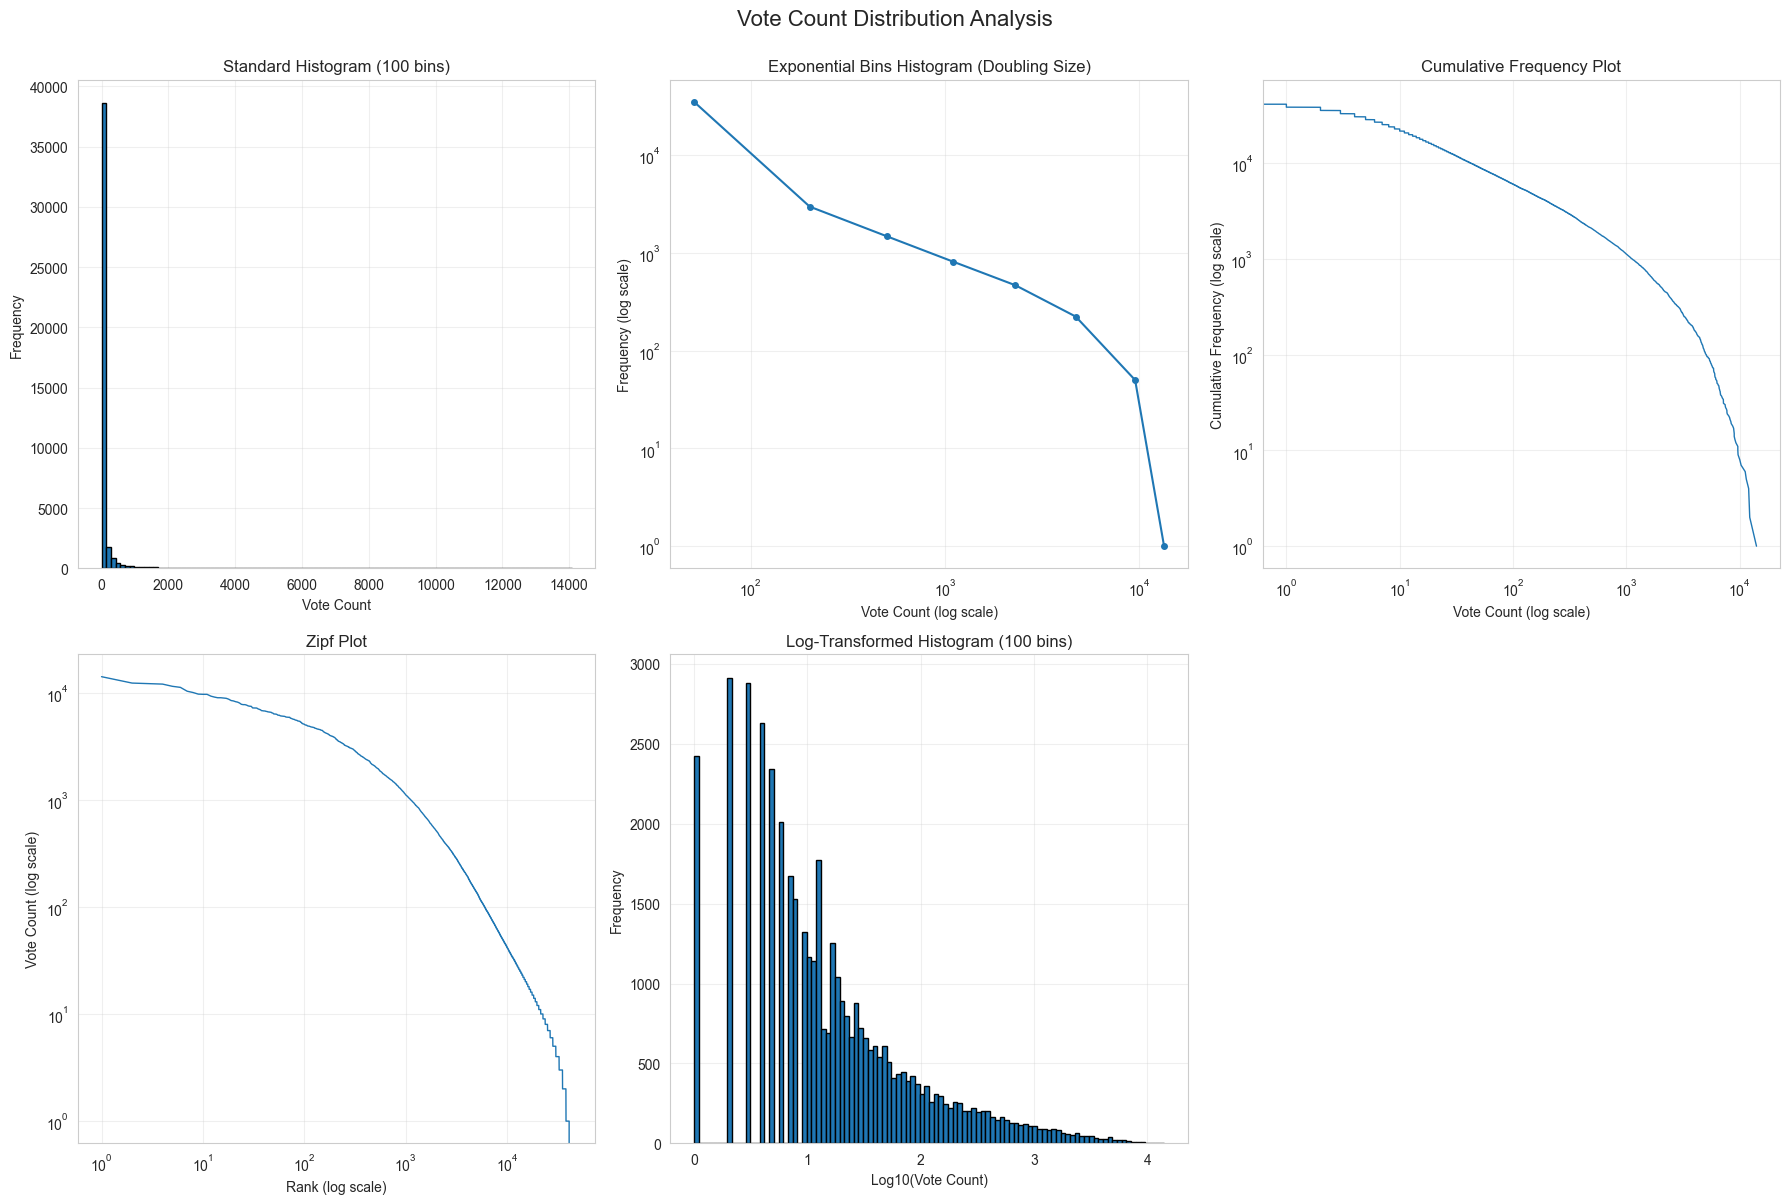

  Bin 1: [1, 101] - Size: 100
  Bin 2: [101, 301] - Size: 200
  Bin 3: [301, 701] - Size: 400
  Bin 4: [701, 1501] - Size: 800
  Bin 5: [1501, 3101] - Size: 1600


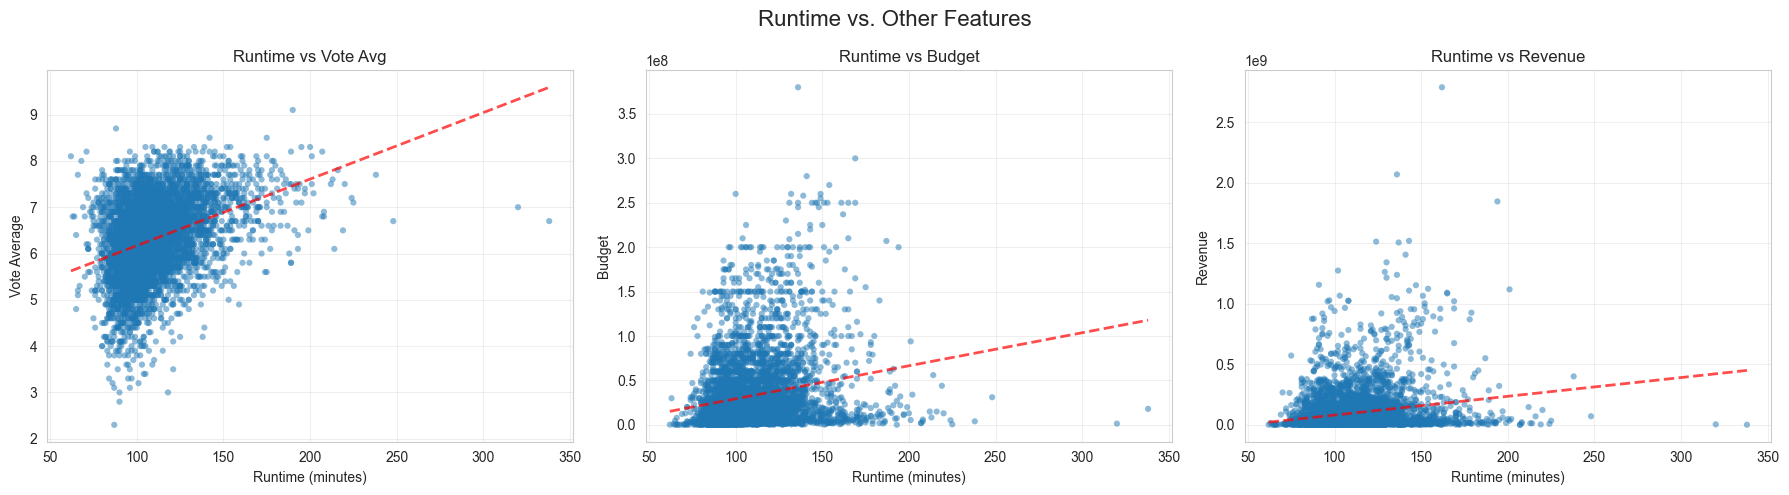


Hypothesis: Longer movies have larger budgets but are less popular

VOTE_AVERAGE:
  Pearson Correlation: 0.3576
  P-value: 1.2382e-150
  Interpretation: *** (highly significant)
Direction: positive (longer runtime - higher value)

BUDGET:
  Pearson Correlation: 0.1930
  P-value: 3.8881e-43
  Interpretation: *** (highly significant)
Direction: positive (longer runtime - higher value)

REVENUE:
  Pearson Correlation: 0.1928
  P-value: 4.7286e-43
  Interpretation: *** (highly significant)
Direction: positive (longer runtime - higher value)
Movies per decade:
decade
1870       2
1880       3
1890      31
1900      28
1910      45
1920     131
1930     315
1940     480
1950     737
1960    1086
1970    1382
1980    2017
1990    2961
2000    6048
2010    7401
Name: count, dtype: int64


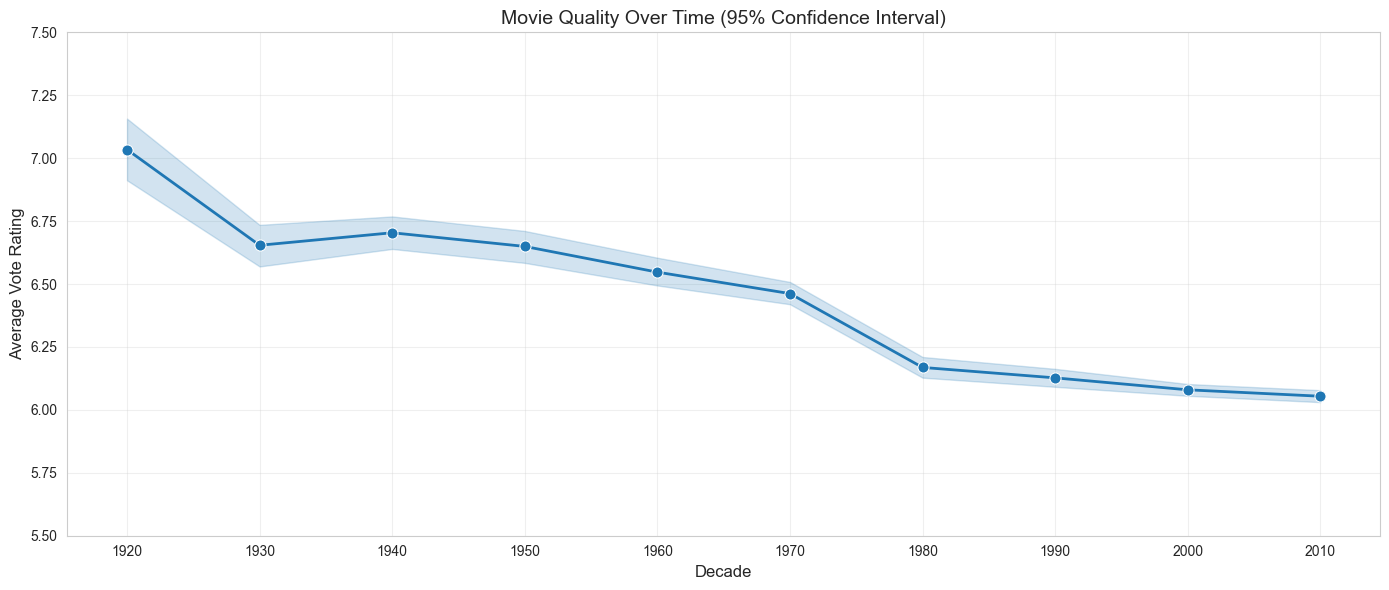

         mean  median    std  count
decade                             
1920    7.034     7.1  0.721    131
1930    6.654     6.7  0.765    315
1940    6.704     6.7  0.721    480
1950    6.649     6.8  0.900    737
1960    6.547     6.6  0.910   1086
1970    6.462     6.6  0.894   1382
1980    6.169     6.2  0.957   2017
1990    6.127     6.2  0.978   2961
2000    6.080     6.2  0.963   6048
2010    6.054     6.1  1.043   7401


Alternative Analysis


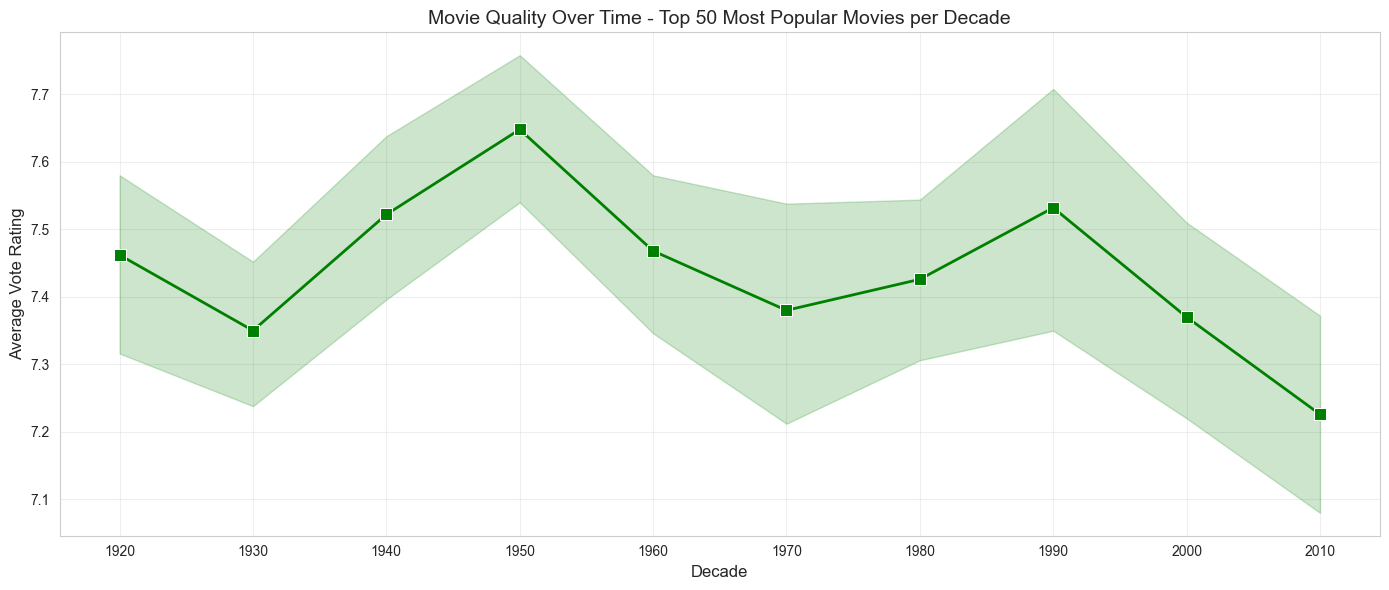


Genre distribution (top 10):
genre
Drama              19803
Comedy             12674
Thriller            7464
Romance             6602
Action              6461
Horror              4595
Crime               4229
Documentary         3762
Adventure           3432
Science Fiction     2990
Name: count, dtype: int64

Kept 20 genres with >100 movies
Filtered genre entries: 88847

Total movies with directors: 27537

Gender distribution:
Female (1): 1693 (6.1%)
Male (2): 25844 (93.9%)

Merged dataset: 57898 entries
genre            Action  Adventure  Animation  Comedy  Crime  Documentary  \
director_gender                                                             
Female               82         55         36     529     76          216   
Male               4254       2341        892    7763   2883         1273   

genre            Drama  Family  Fantasy  Foreign  History  Horror  Music  \
director_gender                                                            
Female             957     

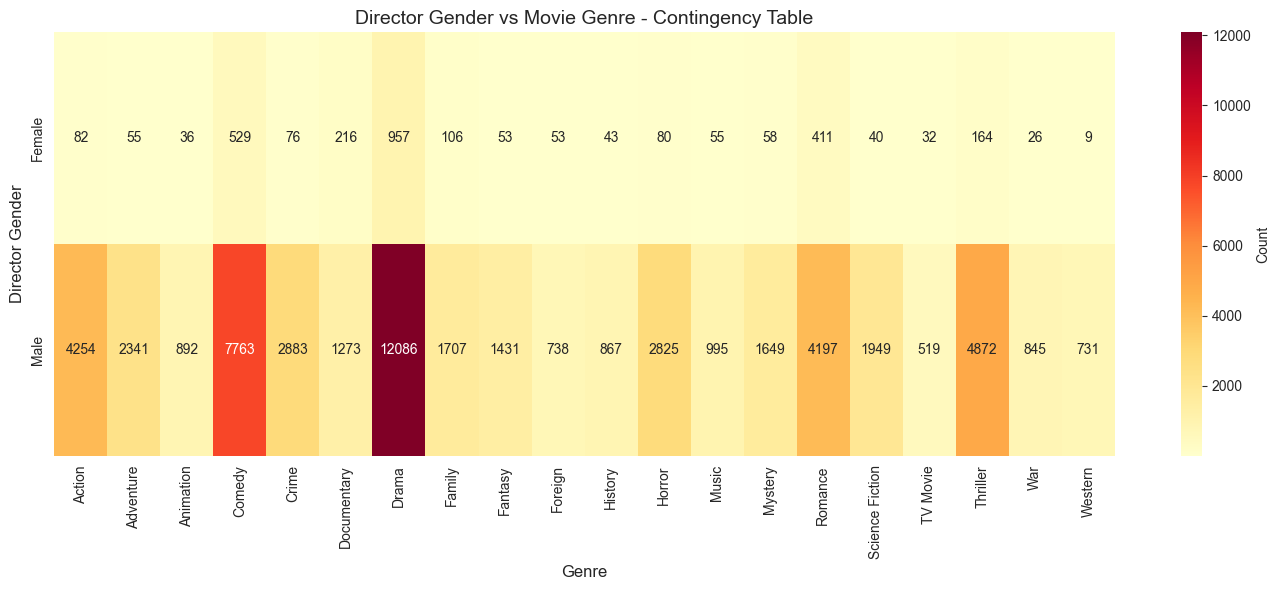


Chi-square statistic: 869.03

P-value: 4.4403e-172

Degrees of freedom: 19
Result: HIGHLY SIGNIFICANT correlation (p < 0.001)
Movies for comparison: 4002
Action: 1414
Drama: 2588


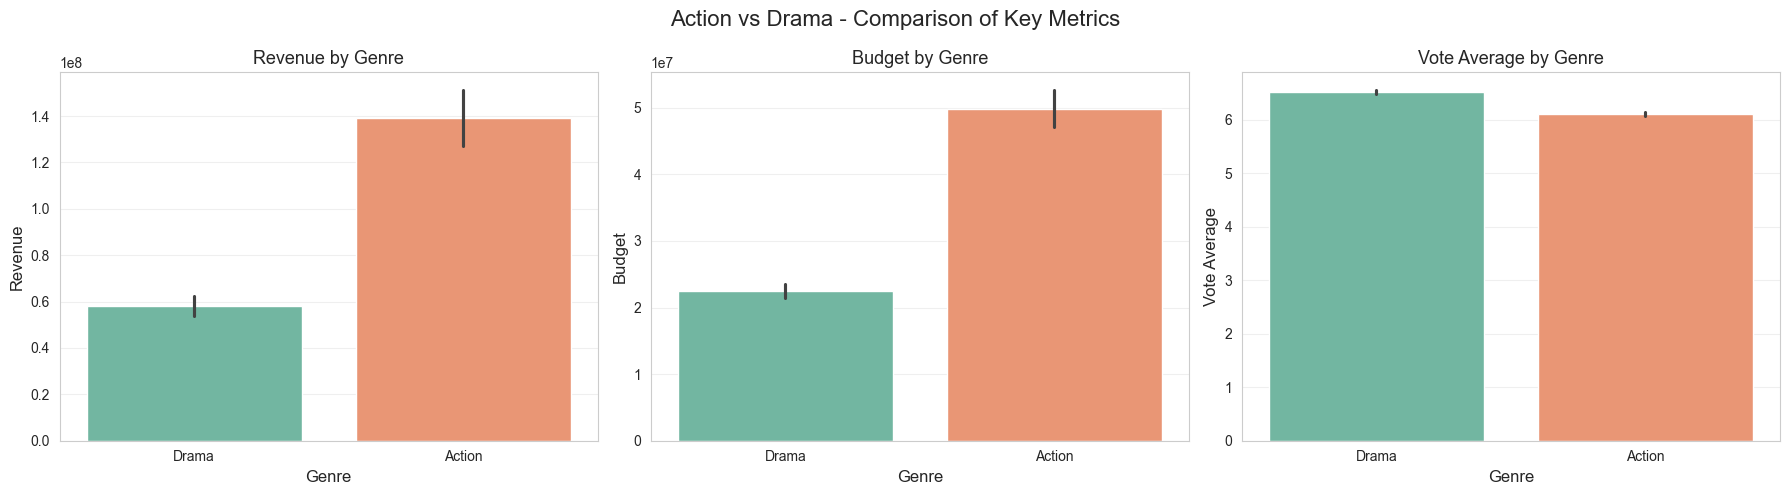


REVENUE:
Action - Mean: 139,147,398.66, Std: 227,613,211.47
Drama  - Mean: 57,898,855.54, Std: 107,300,383.70
Difference: 81,248,543.11
T-statistic: 15.3115
P-value: 1.7993e-51
  Result: HIGHLY SIGNIFICANT
Action movies have significantly HIGHER revenue

BUDGET:
Action - Mean: 49,741,089.59, Std: 53,836,159.58
Drama  - Mean: 22,407,937.93, Std: 27,755,641.61
Difference: 27,333,151.66
T-statistic: 21.1856
P-value: 1.6859e-94
  Result: HIGHLY SIGNIFICANT
Action movies have significantly HIGHER budget

VOTE AVERAGE:
Action - Mean: 6.11, Std: 0.86
Drama  - Mean: 6.53, Std: 0.83
Difference: -0.42
T-statistic: -15.0292
P-value: 1.0507e-49
  Result: HIGHLY SIGNIFICANT
Drama movies have significantly HIGHER vote average
Hypothesis: 'Female directors have smaller budgets than male directors'

Movies with valid budget and director gender: 6590

Female directors: 345 movies
Male directors: 6245 movies

Female Directors:
Mean budget: $18,011,708
Median budget: $8,000,000
Std deviation: $27,884,95

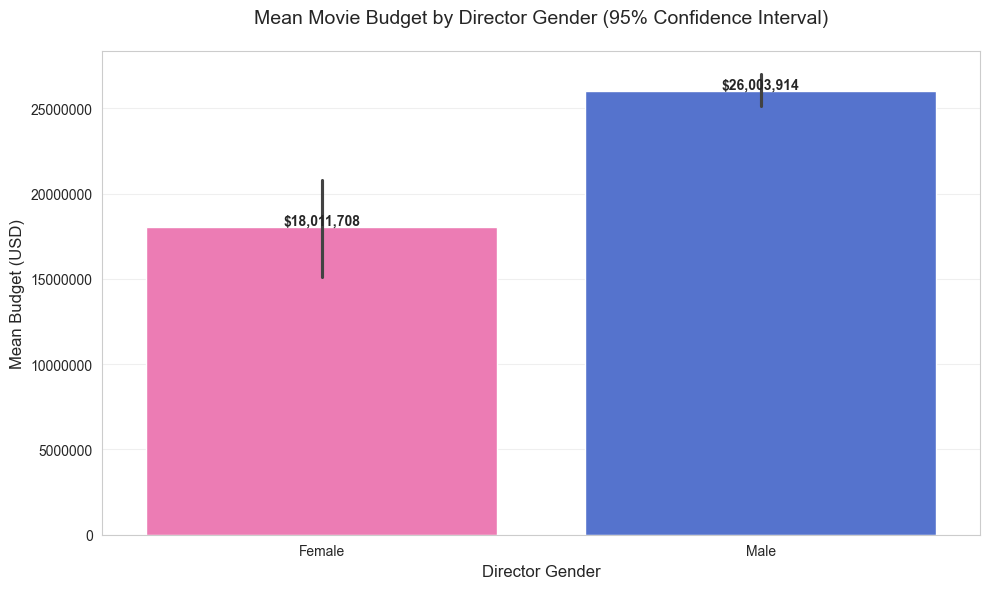

Male directors have 1.44x the mean budget of female directors
Difference in means: $7,992,205
Hypothesis: 'Animated movies have higher vote averages than other genres'
Rationale: Usually animated movies are specifically targeted and well-received by audiences leading to higher votes

Dataset for analysis:
Animation movies: 1868
Other genre movies: 83779


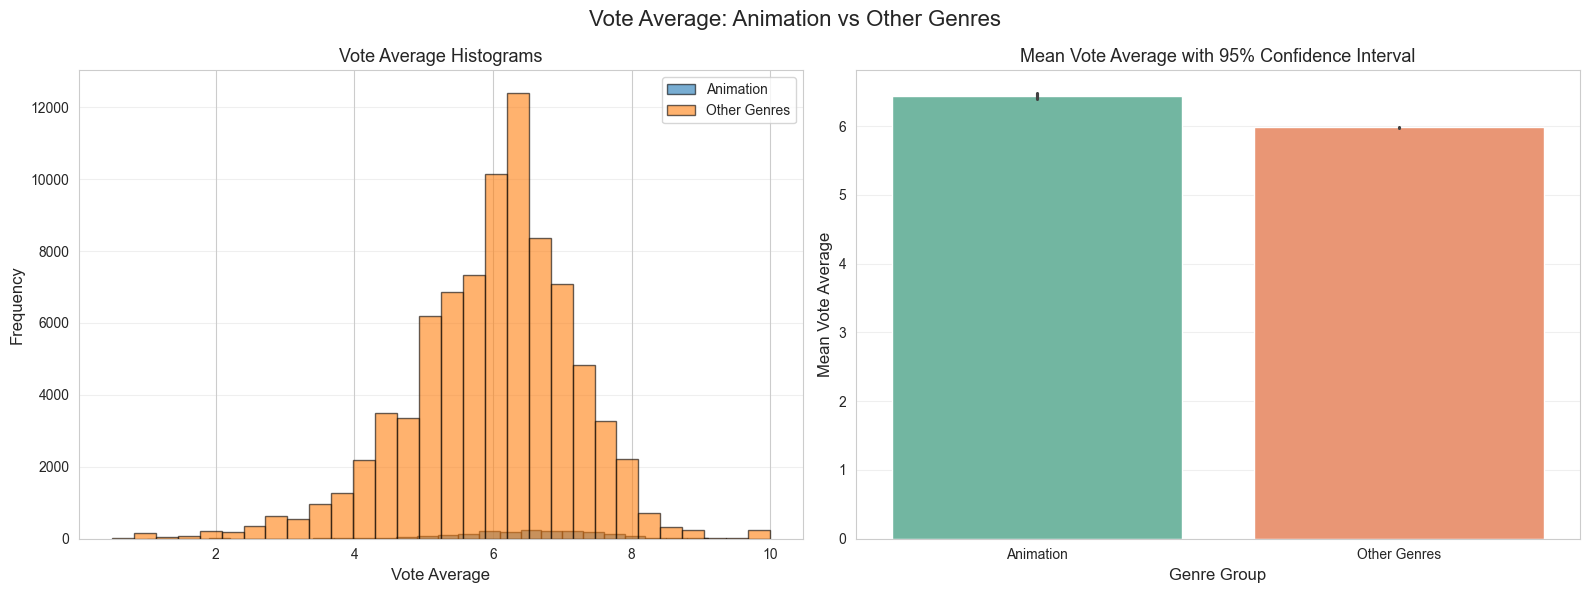


Animation:
Count: 1868
Mean: 6.44
Median: 6.50
Std Dev: 1.04
Range: [1.0, 10.0]

Other Genres:
Count: 83779
Mean: 5.99
Median: 6.10
Std Dev: 1.19
Range: [0.5, 10.0]

Difference in means: 0.46
Null hypothesis: Animation and Other genres have equal mean vote average
Alternative: Mean vote averages are different

T-statistic: 16.3937
P-value: 2.6225e-60
HIGHLY SIGNIFICANT (p < 0.001)
(Non-parametric alternative, doesn't assume normal distribution)
U-statistic: 96664920.5000
P-value: 4.7059e-68
Result: STATISTICALLY SIGNIFICANT
Cohen's d: 0.3835
Interpretation: MEDIUM effect size
                 count  mean  median   std
genre                                     
Documentary       3320  6.67     6.9  1.28
Animation         1868  6.44     6.5  1.04
History           1311  6.42     6.5  1.08
Music             1458  6.36     6.5  1.18
War               1250  6.29     6.4  1.09
Drama            19006  6.19     6.3  1.12
Crime             4091  6.11     6.2  1.07
Romance           6360  6.06 

In [11]:
def main():
    df_clean = step1_load_and_clean()

    step2_vote_distribution(df_clean)

    step3_runtime_correlation(df_clean)

    step4_quality_over_time(df_clean)

    df_genres, df_directors = step5_gender_genre_correlation(df_clean)

    step6_action_vs_drama(df_clean, df_genres)

    step7_gender_budget_hypothesis(df_clean, df_directors)

    step8_custom_hypothesis(df_clean, df_genres)


main()